# MMS at an extremely compressed reconnecting magnetopause

On 11 May 2024, during the Gannon (Mother's Day) geomagnetic storm, MMS crossed a dayside magnetopause compressed to about $7\,R_E$. This advanced notebook combines MMS2 burst-mode magnetic field, plasma moments, particle spectra, and electric field measurements to examine the reconnecting boundary reported by [Beedle et al. (2025)](https://doi.org/10.1029/2025GL118368).

We will proceed from observations to derived quantities:

$$\mathrm{FGM+FPI+EDP}\rightarrow \mathrm{MVA/LMN}\rightarrow \mathbf J
\rightarrow \mathbf E'=\mathbf E+\mathbf V_i\times\mathbf B
\rightarrow \mathbf J\cdot\mathbf E'.$$

This is a single-spacecraft teaching analysis, not a reproduction of every correction in the paper. In particular, the public standard DES electron moments used below are contaminated by low-energy secondary electrons in this unusually dense plasma. The published analysis instead used partial electron moments above 32.8 eV and a spin-tone correction. We apply the documented spin-tone correction but **do not** call the remaining standard moments equivalent to the paper's partial moments.

## 1. Imports and event interval

The six-minute interval retains the earlier partial exhaust near 14:42 UT and the complete $B_L$ reversal near 14:44:15 UT. The tighter interval is used only for focused plots.

In [ ]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.

!pip install "pyspedas>=2.2.0"

In [1]:
%matplotlib inline

from datetime import datetime, timezone
from importlib.metadata import version

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pyspedas
from pyspedas import (
    get_data, minvar, options, set_coords, set_units, store_data,
    time_double, timebar, tplot, tplotxy3,
)
from pyspedas.projects.mms.particles.mms_part_products import mms_part_products
from pyspedas.projects.mms import mms_part_slice2d

print("PySPEDAS version:", version("pyspedas"))

24-Sep-26 10:41:39: /Users/jwl/anaconda3/envs/pycharm_py312/lib/python3.12/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()



PySPEDAS version: 2.2.0


In [2]:
trange = ["2024-05-11/14:40:40", "2024-05-11/14:46:40"]
focused_trange = ["2024-05-11/14:43:00", "2024-05-11/14:45:00"]
main_crossing = "2024-05-11/14:44:15"
partial_crossing = "2024-05-11/14:42:00"
mms = pyspedas.projects.mms

## 2. Load a compact MMS2 burst overview

We request only the product families needed for the core analysis: FGM field, FPI ion/electron moments (which include delivered omni-directional energy spectra), and EDP DC electric field. The EDP burst file is high rate (8192 samples/s), so it is the largest download. PySPEDAS caches downloaded CDFs; avoid deleting the cache between runs.

In [3]:
fgm_vars = mms.fgm(
    probe="2", trange=trange, data_rate="brst",
    varnames=["mms2_fgm_b_gse_brst_l2", "mms2_fgm_flag_brst_l2"],
    time_clip=True,
)
ion_vars = mms.fpi(
    probe="2", trange=trange, data_rate="brst",
    datatype="dis-moms", time_clip=True,
)
electron_vars = mms.fpi(
    probe="2", trange=trange, data_rate="brst",
    datatype="des-moms", time_clip=True,
)
edp_vars = mms.edp(
    probe="2", trange=trange, data_rate="brst", datatype="dce",
    varnames=["mms2_edp_dce_gse_brst_l2"], time_clip=True,
)

print(f"FGM returned {len(fgm_vars)} variables")
print(f"DIS moments returned {len(ion_vars)} variables")
print(f"DES moments returned {len(electron_vars)} variables")
print(f"EDP returned {len(edp_vars)} variables")

24-Sep-26 10:41:40: Loading files for group: probe: 2, drate: brst, level: l2, datatype: , after sorting and filtering:


24-Sep-26 10:41:40: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fgm/brst/l2/2024/05/11/mms2_fgm_brst_l2_20240511143943_v5.451.0.cdf


24-Sep-26 10:41:40: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fgm/brst/l2/2024/05/11/mms2_fgm_brst_l2_20240511144203_v5.451.0.cdf


24-Sep-26 10:41:40: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fgm/brst/l2/2024/05/11/mms2_fgm_brst_l2_20240511144413_v5.451.0.cdf


24-Sep-26 10:41:40: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fgm/brst/l2/2024/05/11/mms2_fgm_brst_l2_20240511144633_v5.451.0.cdf


...

24-Sep-26 10:41:43: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/dce/2024/05/11/mms2_edp_brst_l2_dce_20240511143943_v3.1.2.cdf


24-Sep-26 10:41:43: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/dce/2024/05/11/mms2_edp_brst_l2_dce_20240511144203_v3.1.2.cdf


24-Sep-26 10:41:43: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/dce/2024/05/11/mms2_edp_brst_l2_dce_20240511144413_v3.1.2.cdf


24-Sep-26 10:41:43: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/dce/2024/05/11/mms2_edp_brst_l2_dce_20240511144633_v3.1.2.cdf


FGM returned 4 variables
DIS moments returned 48 variables
DES moments returned 55 variables
EDP returned 1 variables


### Inspect names, cadence, units, and coordinates

MMS names encode spacecraft, instrument, quantity, coordinates, cadence, and sometimes processing level. We select explicit names only after inspecting the loader output. The spectra are scalar energy-bin products; all vectors combined later must be in GSE first.

In [4]:
b_gse_var = "mms2_fgm_b_gse_brst_l2"
b_flag_var = "mms2_fgm_flag_brst_l2"
ion_spectrum_var = "mms2_dis_energyspectr_omni_brst"
electron_spectrum_var = "mms2_des_energyspectr_omni_brst"
ion_density_var = "mms2_dis_numberdensity_brst"
electron_density_var = "mms2_des_numberdensity_brst"
ion_velocity_var = "mms2_dis_bulkv_gse_brst"
electron_velocity_var = "mms2_des_bulkv_gse_brst"
electron_spintone_var = "mms2_des_bulkv_spintone_gse_brst"
e_gse_var = "mms2_edp_dce_gse_brst_l2"

expected = [
    b_gse_var, b_flag_var, ion_spectrum_var, electron_spectrum_var,
    ion_density_var, electron_density_var, ion_velocity_var,
    electron_velocity_var, electron_spintone_var, e_gse_var,
]
for name in expected:
    if get_data(name) is None:
        raise RuntimeError(f"Expected variable {name!r} was not loaded")

def summarize(name):
    data = get_data(name)
    metadata = get_data(name, metadata=True)
    values = np.asarray(data.y)
    attrs = metadata["data_att"]
    print(
        f"{name:39s} shape={str(values.shape):15s} "
        f"dt={np.nanmedian(np.diff(data.times)):9.6f} s  "
        f"coord={attrs.get('coord_sys')!r:6s} units={attrs.get('units')!r}"
    )

for name in expected:
    summarize(name)

for name in [b_gse_var, ion_velocity_var, electron_velocity_var,
             electron_spintone_var, e_gse_var]:
    coordinate = get_data(name, metadata=True)["data_att"]["coord_sys"]
    assert coordinate.upper() == "GSE", f"{name} is not in GSE"

mms2_fgm_b_gse_brst_l2                  shape=(46079, 4)      dt= 0.007812 s  coord='GSE'  units='nT'
mms2_fgm_flag_brst_l2                   shape=(46079,)        dt= 0.007812 s  coord=''     units=''
mms2_dis_energyspectr_omni_brst         shape=(2400, 32)      dt= 0.150000 s  coord=''     units='keV/(cm^2 s sr keV)'
mms2_des_energyspectr_omni_brst         shape=(12000, 32)     dt= 0.030000 s  coord=''     units='keV/(cm^2 s sr keV)'
mms2_dis_numberdensity_brst             shape=(2400,)         dt= 0.150000 s  coord=''     units='cm^-3'
mms2_des_numberdensity_brst             shape=(12000,)        dt= 0.030000 s  coord=''     units='cm^-3'
mms2_dis_bulkv_gse_brst                 shape=(2400, 3)       dt= 0.150000 s  coord='GSE'  units='km/s'
mms2_des_bulkv_gse_brst                 shape=(12000, 3)      dt= 0.030000 s  coord='GSE'  units='km/s'
mms2_des_bulkv_spintone_gse_brst        shape=(12000, 3)      dt= 0.030000 s  coord='GSE'  units='km/s'
mms2_edp_dce_gse_brst_l2              

The fourth FGM column is $|\mathbf B|$; the first three are the GSE vector. The FPI ion and electron moments have 150 ms and 30 ms cadence, respectively. EDP is much faster. Later we average EDP into DES-centered 30 ms bins rather than selecting one noisy high-rate sample.

The metadata for `mms2_des_bulkv_spintone_gse_brst` describes it as the estimated systematic spin-tone error and explicitly says to **subtract** it from the delivered bulk velocity. It is not itself an electron velocity.

## 3. Check the four-spacecraft geometry first

Four spacecraft enable spatial gradients only when their formation is sufficiently three-dimensional. MMS supplies a mission-operations tetrahedron quality factor: values near 1 indicate a regular tetrahedron, whereas values near 0 indicate a degenerate formation. We load a 24-hour orbit-scale interval centered on this event before considering any curlometer or reciprocal-vector calculation.

The ancillary quality product has a long gap containing this crossing. We show that gap explicitly and **do not interpolate a quality factor across it**. A simultaneous position snapshot provides an independent geometric check at the target time.

In [5]:
orbit_quality_trange = [
    "2024-05-11/02:44:15",
    "2024-05-12/02:44:15",
]
quality_vars = mms.tetrahedron_qf(trange=orbit_quality_trange)
quality_var = "mms_tetrahedron_qf"
quality_data = get_data(quality_var)
if quality_data is None:
    raise RuntimeError("The MMS tetrahedron quality-factor product was not loaded")

quality_cadence = np.nanmedian(np.diff(quality_data.times))
quality_gap_indices = np.flatnonzero(
    np.diff(quality_data.times) > 5 * quality_cadence
)
target_time = time_double(main_crossing)
nearest_quality_index = np.argmin(np.abs(quality_data.times - target_time))
nearest_quality_offset = abs(
    quality_data.times[nearest_quality_index] - target_time
)
quality_available_at_target = nearest_quality_offset <= 2 * quality_cadence

print(f"Quality-factor cadence: {quality_cadence:.1f} s")
print(f"Quality samples in 24 h: {len(quality_data.times)}")
print("Quality sample available at target:", quality_available_at_target)
print(f"Nearest quality sample is {nearest_quality_offset / 3600:.2f} h away")

24-Sep-26 10:41:46: Loading /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/ancillary/mms/tetrahedron_qf/MMS_DEFQ_2024131_2024132.V00


24-Sep-26 10:41:46: Loading /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/ancillary/mms/tetrahedron_qf/MMS_DEFQ_2024132_2024133.V00


24-Sep-26 10:41:46: Loading /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/ancillary/mms/tetrahedron_qf/MMS_DEFQ_2024133_2024134.V00


Quality-factor cadence: 30.0 s
Quality samples in 24 h: 1499
Quality sample available at target: False
Nearest quality sample is 3.08 h away


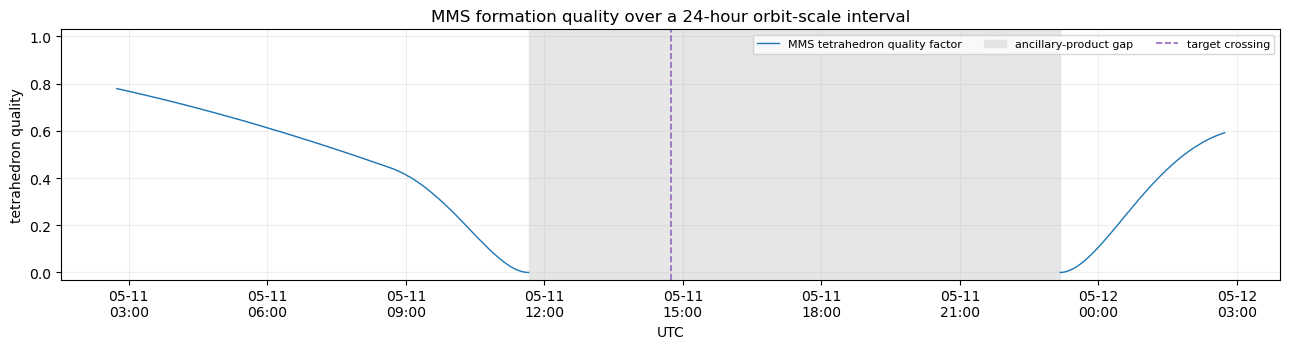

In [6]:
quality_datetimes = np.array([
    datetime.fromtimestamp(t, tz=timezone.utc) for t in quality_data.times
])
segment_starts = np.r_[0, quality_gap_indices + 1]
segment_stops = np.r_[quality_gap_indices + 1, len(quality_data.times)]

fig, ax = plt.subplots(figsize=(13, 3.6))
for segment, (start, stop) in enumerate(zip(segment_starts, segment_stops)):
    ax.plot(
        quality_datetimes[start:stop], quality_data.y[start:stop],
        color="blue", lw=1,
        label="MMS tetrahedron quality factor" if segment == 0 else None,
    )

for gap_index in quality_gap_indices:
    gap_start = quality_datetimes[gap_index]
    gap_stop = quality_datetimes[gap_index + 1]
    ax.axvspan(
        gap_start, gap_stop, color="0.88", alpha=0.8,
        label="ancillary-product gap"
        if gap_start.timestamp() < target_time < gap_stop.timestamp() else None,
    )

target_datetime = datetime.fromtimestamp(target_time, tz=timezone.utc)
ax.axvline(target_datetime, color="purple", ls="--", lw=1.2,
           label="target crossing")
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel("tetrahedron quality")
ax.set_xlabel("UTC")
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d\n%H:%M", tz=timezone.utc)
)
ax.grid(alpha=0.2)
ax.legend(loc="upper right", ncol=3, fontsize=8)
ax.set_title("MMS formation quality over a 24-hour orbit-scale interval")
fig.tight_layout()

The target lies inside an approximately 11.5-hour ancillary-product gap, bracketed by zero-quality samples. It would be misleading to interpolate those endpoints and report a numerical quality factor at 14:44:15 UT. Instead, we now inspect the definitive MEC positions of all four spacecraft at that exact timestamp.

In [7]:
formation_trange = ["2024-05-11/14:43:15", "2024-05-11/14:45:15"]
position_names = [f"mms{probe}_mec_r_gse" for probe in range(1, 5)]
mec_position_vars = mms.mec(
    probe=["1", "2", "3", "4"],
    trange=formation_trange,
    data_rate="srvy", level="l2", datatype="epht89q",
    varnames=position_names, time_clip=True,
)

formation_positions_gse_km = []
for position_name in position_names:
    position_data = get_data(position_name)
    if position_data is None:
        raise RuntimeError(f"Missing MEC position {position_name!r}")
    position = np.array([
        np.interp(target_time, position_data.times, position_data.y[:, component])
        for component in range(3)
    ])
    formation_positions_gse_km.append(position)

formation_positions_gse_km = np.asarray(formation_positions_gse_km)
formation_barycenter_gse_km = np.mean(formation_positions_gse_km, axis=0)
formation_relative_gse_km = (
    formation_positions_gse_km - formation_barycenter_gse_km
)

formation_vars = []
for probe, relative_position in enumerate(formation_relative_gse_km, start=1):
    formation_name = f"mms{probe}_formation_relative_gse"
    store_data(
        formation_name,
        data={"x": np.array([target_time]),
              "y": relative_position[None, :]},
    )
    set_units(formation_name, "km")
    set_coords(formation_name, "GSE")
    formation_vars.append(formation_name)

pairwise_separations_km = np.array([
    np.linalg.norm(formation_positions_gse_km[first]
                   - formation_positions_gse_km[second])
    for first in range(4) for second in range(first + 1, 4)
])
principal_extents_km = np.linalg.svd(
    formation_relative_gse_km, compute_uv=False
)
principal_extent_ratios = principal_extents_km / principal_extents_km[0]

print("Formation barycenter GSE [R_E]:",
      (formation_barycenter_gse_km / 6371.2).round(4))
print("Pairwise separation range [km]:",
      pairwise_separations_km.min().round(2), "to",
      pairwise_separations_km.max().round(2))
print("Principal formation extents [km]:",
      principal_extents_km.round(2))
print("Normalized principal extents:",
      principal_extent_ratios.round(3))

24-Sep-26 10:41:47: Loading files for group: probe: 1, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:


24-Sep-26 10:41:47: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms1/mec/srvy/l2/epht89q/2024/05/mms1_mec_srvy_l2_epht89q_20240511_v2.2.3.cdf


24-Sep-26 10:41:47: Loading files for group: probe: 2, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:


24-Sep-26 10:41:47: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/mec/srvy/l2/epht89q/2024/05/mms2_mec_srvy_l2_epht89q_20240511_v2.2.2.cdf


24-Sep-26 10:41:47: Loading files for group: probe: 3, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:


...

24-Sep-26 10:41:47: Setting units for mms3_formation_relative_gse


24-Sep-26 10:41:47: Setting coordinate system for mms3_formation_relative_gse


24-Sep-26 10:41:47: Setting units for mms4_formation_relative_gse


24-Sep-26 10:41:47: Setting coordinate system for mms4_formation_relative_gse


Formation barycenter GSE [R_E]: [ 6.0383 -2.9316 -0.0195]
Pairwise separation range [km]: 15.26 to 75.54
Principal formation extents [km]: [60.69 15.45  1.78]
Normalized principal extents: [1.    0.255 0.029]


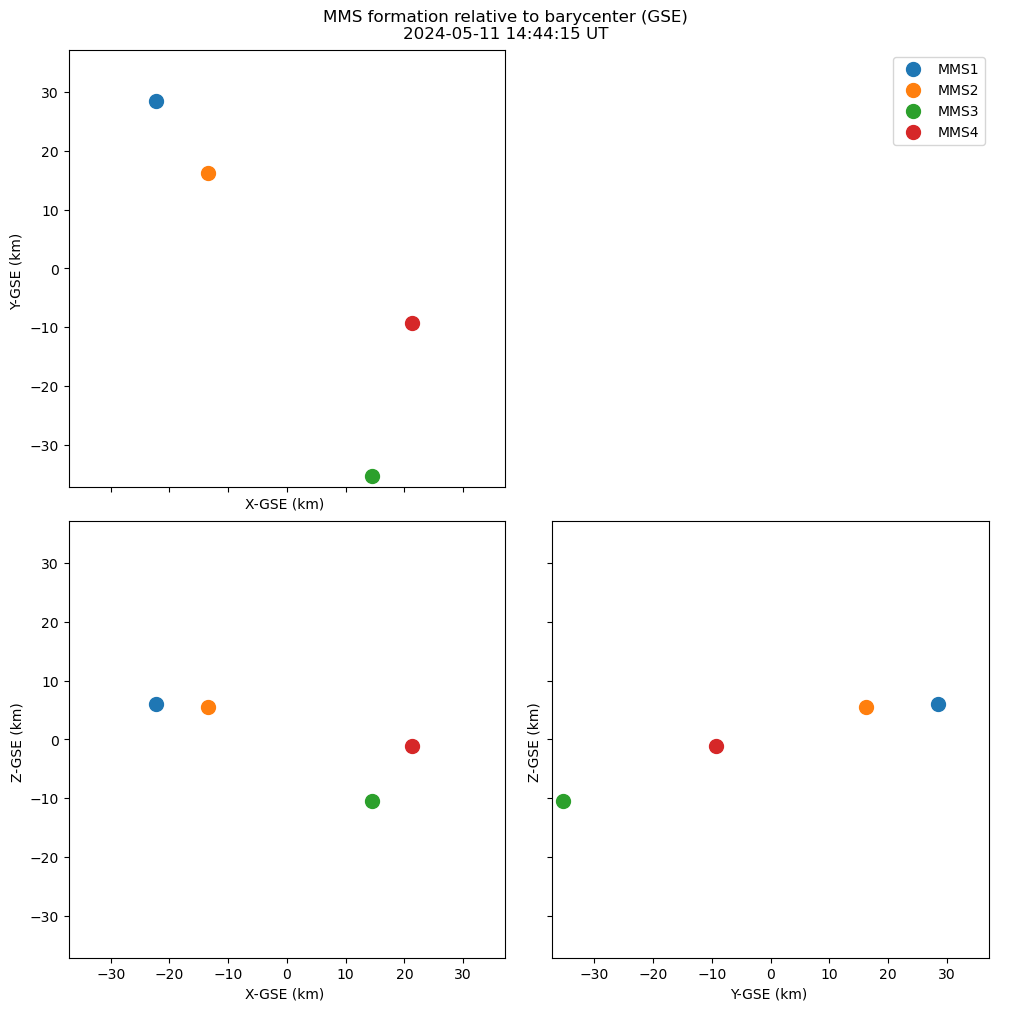

In [8]:
formation_figure = tplotxy3(
    formation_vars,
    center_origin=True,
    plot_units="km",
    colors=["blue", "orange", "green", "red"],
    linestyles=["None"] * 4,
    markers=["o"] * 4,
    markevery=1,
    markersize=10,
    legend_names=["MMS1", "MMS2", "MMS3", "MMS4"],
    show_centerbody=False,
    title=("MMS formation relative to barycenter (GSE)\n"
           "2024-05-11 14:44:15 UT"),
)

The barycenter is near $[6.04,-2.93,-0.02]~R_E$, while the six pairwise separations span roughly 15–76 km. More importantly, the three principal formation extents are in the approximate ratio $1:0.25:0.03$: the constellation is nearly collapsed along its third dimension. The position snapshot therefore supplies direct geometric evidence that tetrahedral gradients are ill conditioned here, even though the quality-factor product itself is unavailable at the event.

## 4. First look in GSE coordinates

These are the ordinary public FPI moments. Use this overview to locate boundaries before applying a coordinate transform. The vertical purple guide marks the published complete crossing; the gray guide marks the approximate earlier partial crossing.

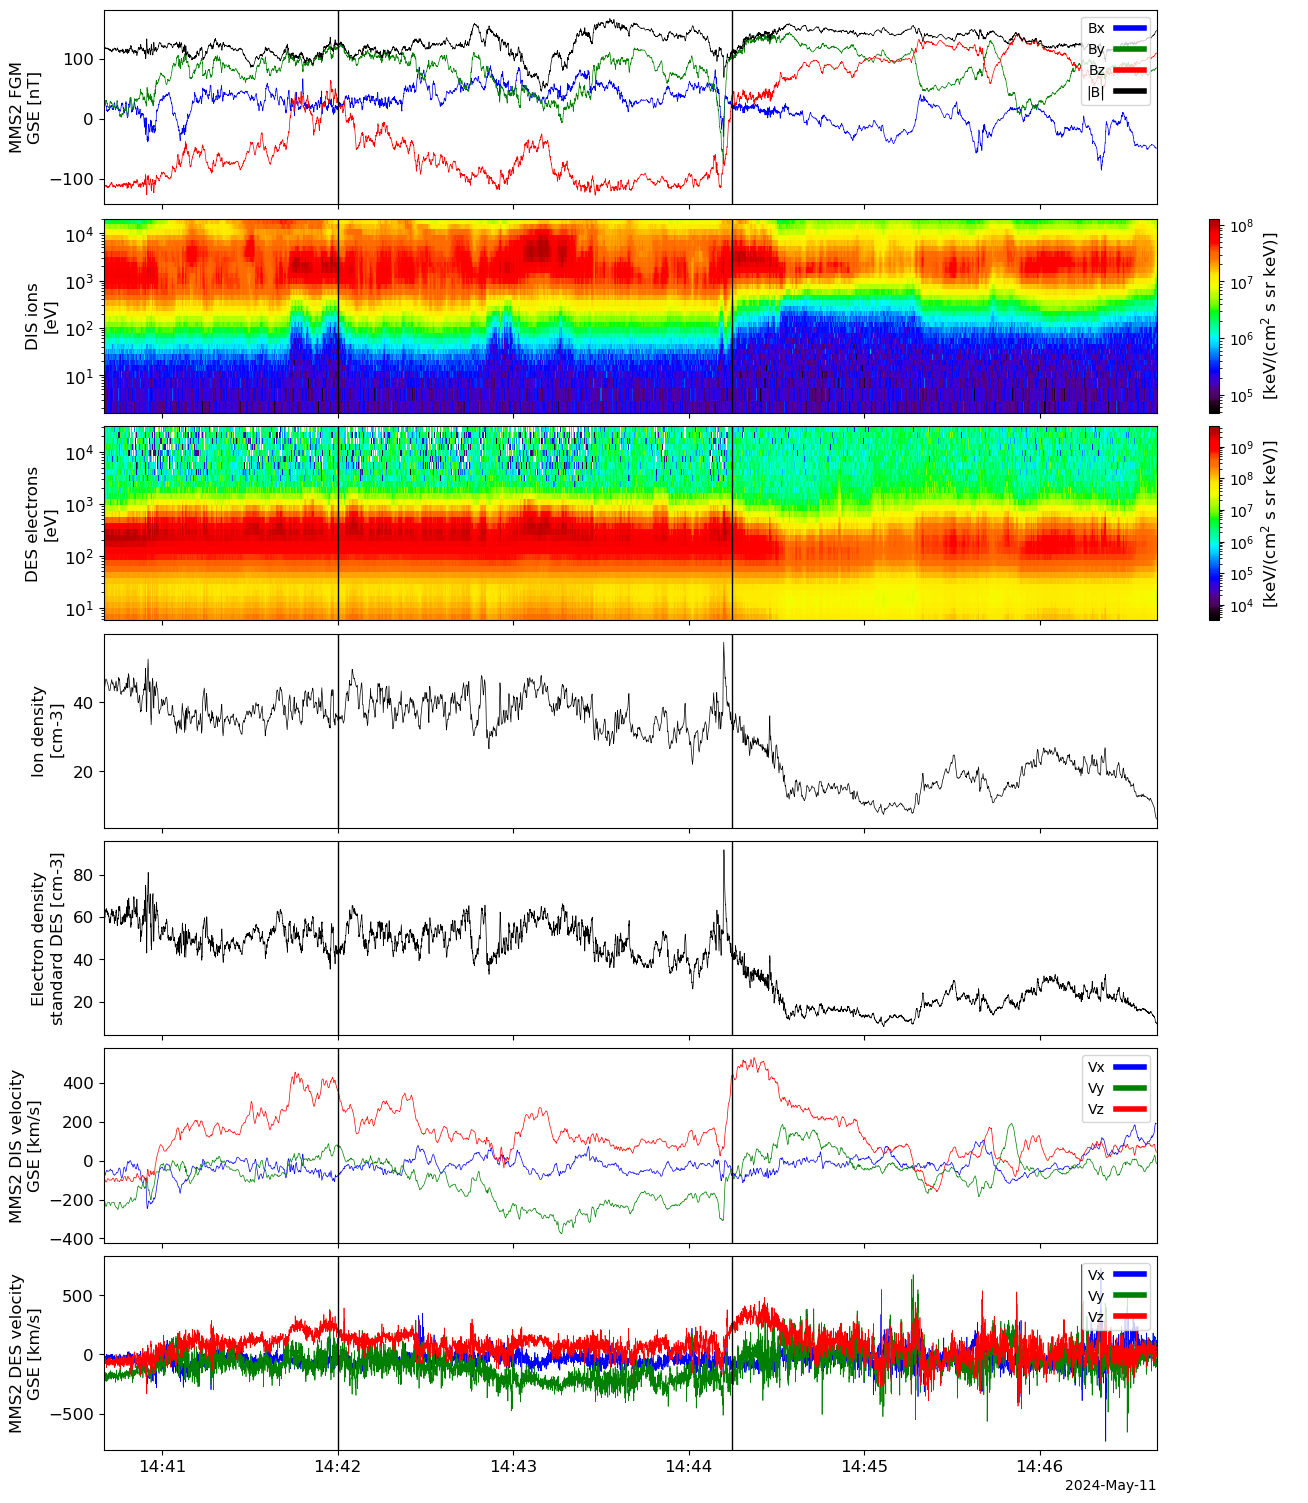

In [9]:
options(b_gse_var, "legend_names", ["Bx", "By", "Bz", "|B|"])
options(b_gse_var, "ysubtitle", "GSE [nT]")
for name, title in [(ion_spectrum_var, "DIS ions"),
                    (electron_spectrum_var, "DES electrons")]:
    options(name, "ylog", True)
    options(name, "zlog", True)
    options(name, "ytitle", title)
options(ion_density_var, "ytitle", "Ion density")
options(ion_density_var, "ysubtitle", "[cm^-3]")
options(electron_density_var, "ytitle", "Electron density")
options(electron_density_var, "ysubtitle", "standard DES [cm^-3]")
options(ion_velocity_var, "legend_names", ["Vx", "Vy", "Vz"])
options(ion_velocity_var, "ysubtitle", "GSE [km/s]")
options(electron_velocity_var, "legend_names", ["Vx", "Vy", "Vz"])
options(electron_velocity_var, "ysubtitle", "GSE [km/s]")

timebar(time_double(partial_crossing), color="0.45", thick=1)
timebar(time_double(main_crossing), color="purple", thick=1)
tplot(
    [b_gse_var, ion_spectrum_var, electron_spectrum_var,
     ion_density_var, electron_density_var, ion_velocity_var,
     electron_velocity_var],
    xsize=13, ysize=15,
)

Direct observations include a strong field rotation/reversal, large density changes, energetic changes, and flow structure. Beedle et al. interpret the complete traversal at about 14:44:15 UT as separating the Outer Magnetopause from the low-latitude boundary layer within a reconnection exhaust. The measurements support a reconnecting-boundary interpretation, but one zero crossing by itself is not proof that MMS crossed an X line.

## 5. Minimum variance analysis and an LMN frame

`minvar` orders eigenvalues from maximum to minimum variance and returns the eigenvectors as **columns**. We transpose them so the rows of `R_gse_to_lmn` are $L$, $M$, and $N$ expressed in GSE. Eigenvector signs are arbitrary, so we choose signs for comparison with the published basis and then enforce a proper, right-handed rotation.

In [10]:
b_data = get_data(b_gse_var)
b_flag_data = get_data(b_flag_var)
b_gse = np.asarray(b_data.y)[:, :3]
mva_mask = np.all(np.isfinite(b_gse), axis=1) & (b_flag_data.y == 0)

_, eigenvectors, eigenvalues = minvar(b_gse[mva_mask])
R_gse_to_lmn = eigenvectors.T.copy()

published_R = np.array([
    [-0.205,  0.165,  0.965],
    [-0.374, -0.924,  0.078],
    [ 0.904, -0.345,  0.251],
])

# Align each arbitrary eigenvector sign with its corresponding published axis.
for row in range(3):
    if np.dot(R_gse_to_lmn[row], published_R[row]) < 0:
        R_gse_to_lmn[row] *= -1

# A rotation (unlike a reflection) must have determinant +1.
if np.linalg.det(R_gse_to_lmn) < 0:
    agreement = np.abs(np.diag(R_gse_to_lmn @ published_R.T))
    R_gse_to_lmn[np.argmin(agreement)] *= -1

signed_dots = np.diag(R_gse_to_lmn @ published_R.T)
axis_angles = np.degrees(np.arccos(np.clip(np.abs(signed_dots), 0, 1)))

print("Eigenvalues [maximum, intermediate, minimum] (nT^2):")
print(np.array2string(eigenvalues, precision=3))
print(f"lambda_L/lambda_M = {eigenvalues[0] / eigenvalues[1]:.2f}")
print(f"lambda_M/lambda_N = {eigenvalues[1] / eigenvalues[2]:.2f}")
print("\nR_GSE_to_LMN (rows are L, M, N in GSE):")
print(np.array2string(R_gse_to_lmn, precision=5, suppress_small=True))
print("\nPublished basis:")
print(np.array2string(published_R, precision=5, suppress_small=True))
print("Axis separations ignoring sign (degrees):", axis_angles.round(2))
print(f"det(R) = {np.linalg.det(R_gse_to_lmn):.6f}")

assert np.allclose(R_gse_to_lmn @ R_gse_to_lmn.T, np.eye(3), atol=1e-12)
assert np.linalg.det(R_gse_to_lmn) > 0

Eigenvalues [maximum, intermediate, minimum] (nT^2):
[8054.781  992.508  421.254]
lambda_L/lambda_M = 8.12
lambda_M/lambda_N = 2.36

R_GSE_to_LMN (rows are L, M, N in GSE):
[[-0.2441   0.09325  0.96526]
 [ 0.02123 -0.99461  0.10146]
 [ 0.96952  0.04526  0.24081]]

Published basis:
[[-0.205  0.165  0.965]
 [-0.374 -0.924  0.078]
 [ 0.904 -0.345  0.251]]
Axis separations ignoring sign (degrees): [ 4.51 23.22 22.89]
det(R) = 1.000000


The maximum-variance axis should be close to the published $L$. Agreement of $M$ and $N$ can be weaker because the intermediate/minimum eigenvalue separation is modest. Do not tune the time interval to force a match: cadence, valid-sample selection, preprocessing, and boundary-coordinate construction all matter.

## 6. Rotate field and flows consistently

For one column vector, $\mathbf v_{LMN}=R\mathbf v_{GSE}$. Samples here are rows, so the vectorized equivalent is `v_gse @ R.T`. The corrected standard DES velocity is the delivered velocity minus the delivered spin-tone error estimate.

In [11]:
ion_velocity_data = get_data(ion_velocity_var)
electron_velocity_data = get_data(electron_velocity_var)
electron_spintone_data = get_data(electron_spintone_var)

assert np.array_equal(electron_velocity_data.times, electron_spintone_data.times)
electron_velocity_corrected_gse = (
    electron_velocity_data.y - electron_spintone_data.y
)

b_lmn = b_gse @ R_gse_to_lmn.T
ion_velocity_lmn = ion_velocity_data.y @ R_gse_to_lmn.T
electron_velocity_lmn = electron_velocity_corrected_gse @ R_gse_to_lmn.T

store_data("mms2_fgm_b_lmn_brst", data={"x": b_data.times, "y": b_lmn})
store_data(
    "mms2_dis_bulkv_lmn_brst",
    data={"x": ion_velocity_data.times, "y": ion_velocity_lmn},
)
store_data(
    "mms2_des_bulkv_lmn_brst_standard_corrected",
    data={"x": electron_velocity_data.times, "y": electron_velocity_lmn},
)
options("mms2_fgm_b_lmn_brst", "legend_names", ["B_L", "B_M", "B_N"])
options("mms2_dis_bulkv_lmn_brst", "legend_names", ["V_iL", "V_iM", "V_iN"])
options(
    "mms2_des_bulkv_lmn_brst_standard_corrected", "legend_names",
    ["V_eL", "V_eM", "V_eN"],
)

# Locate the closest B_L zero only inside a +/-10 s window around the published crossing.
cross_window = np.abs(b_data.times - time_double(main_crossing)) <= 10
candidate_indices = np.flatnonzero(cross_window)
zero_index = candidate_indices[np.nanargmin(np.abs(b_lmn[cross_window, 0]))]
zero_time = datetime.fromtimestamp(float(b_data.times[zero_index]), tz=timezone.utc)
print(f"Closest B_L=0 sample near the main crossing: {zero_time:%H:%M:%S.%f} UT")
print("B_LMN at that sample [nT]:", b_lmn[zero_index].round(2))

Closest B_L=0 sample near the main crossing: 14:44:13.849861 UT
B_LMN at that sample [nT]: [-2.000e-02 -9.608e+01  3.086e+01]


## 7. Reconnection signatures in LMN

The next figure is an original diagnostic layout, not a copy of the published figure. The black dashed line on the electron spectrogram marks 32.8 eV—the lower boundary used for the paper's partial moments. The spectra themselves remain the delivered omni-directional spectra.

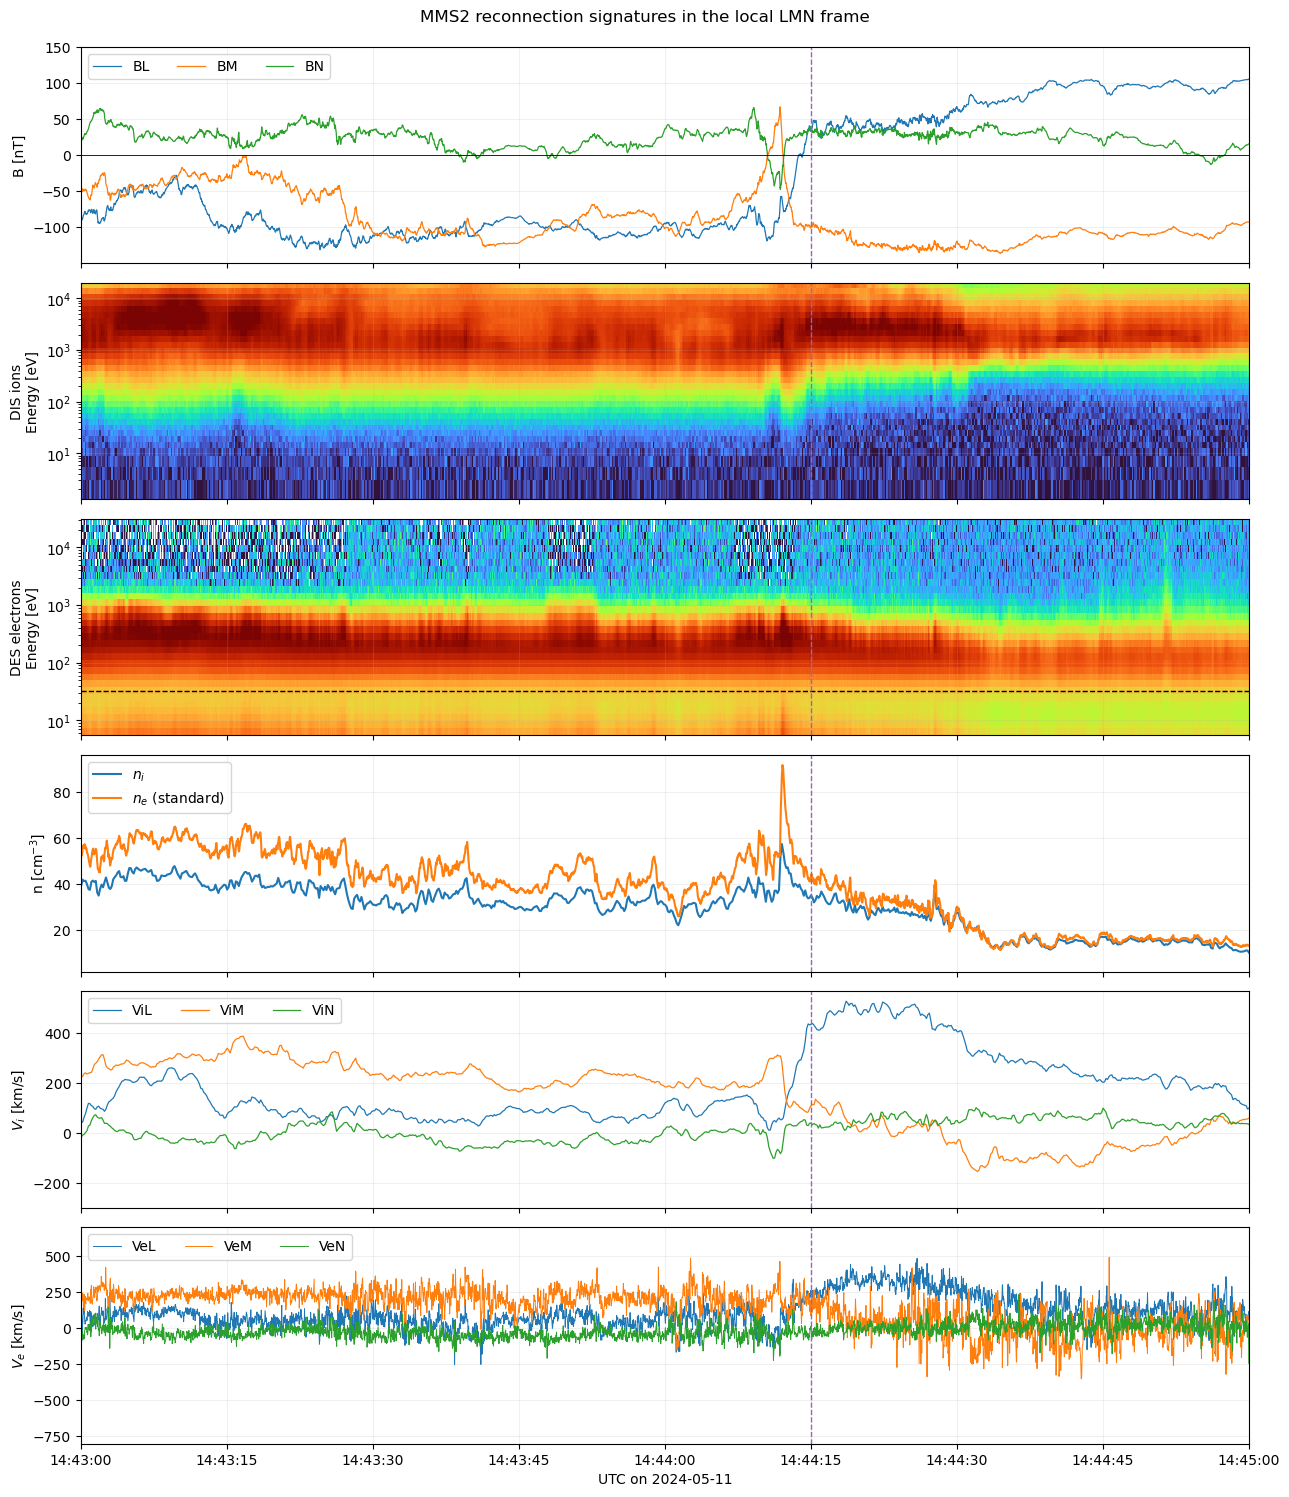

In [12]:
def utc_datetimes(times):
    return [datetime.fromtimestamp(float(t), tz=timezone.utc) for t in times]

def add_spectrogram(ax, variable, label, cutoff=None):
    data = get_data(variable)
    energies = np.nanmedian(np.asarray(data.v), axis=0)
    values = np.where(np.asarray(data.y) > 0, data.y, np.nan)
    finite = values[np.isfinite(values)]
    norm = LogNorm(vmin=np.nanpercentile(finite, 2),
                   vmax=np.nanpercentile(finite, 99.5))
    mesh = ax.pcolormesh(
        utc_datetimes(data.times), energies, values.T,
        shading="auto", cmap="turbo", norm=norm,
    )
    ax.set_yscale("log")
    ax.set_ylabel(label + "\nEnergy [eV]")
    if cutoff is not None:
        ax.axhline(cutoff, color="black", ls="--", lw=1.0)
    return mesh

ion_density_data = get_data(ion_density_var)
electron_density_data = get_data(electron_density_var)
plot_start, plot_stop = [
    datetime.fromtimestamp(t, tz=timezone.utc)
    for t in time_double(focused_trange)
]
crossing_dt = datetime.fromtimestamp(time_double(main_crossing), tz=timezone.utc)

fig, axes = plt.subplots(6, 1, figsize=(13, 15), sharex=True)
colors = ["blue", "orange", "green"]
for component, (label, color) in enumerate(zip(["L", "M", "N"], colors)):
    axes[0].plot(utc_datetimes(b_data.times), b_lmn[:, component],
                 color=color, lw=0.9, label=f"B{label}")
axes[0].axhline(0, color="black", lw=0.6)
axes[0].set_ylabel("B [nT]")
axes[0].legend(ncol=3, loc="upper left")

add_spectrogram(axes[1], ion_spectrum_var, "DIS ions")
add_spectrogram(axes[2], electron_spectrum_var, "DES electrons", cutoff=32.8)

axes[3].plot(utc_datetimes(ion_density_data.times), ion_density_data.y,
             color="blue", label=r"$n_i$")
axes[3].plot(utc_datetimes(electron_density_data.times), electron_density_data.y,
             color="orange", label=r"$n_e$ (standard)")
axes[3].set_ylabel(r"n [cm$^{-3}$]")
axes[3].legend(loc="upper left")

for component, (label, color) in enumerate(zip(["L", "M", "N"], colors)):
    axes[4].plot(utc_datetimes(ion_velocity_data.times), ion_velocity_lmn[:, component],
                 color=color, lw=0.9, label=f"Vi{label}")
    axes[5].plot(utc_datetimes(electron_velocity_data.times), electron_velocity_lmn[:, component],
                 color=color, lw=0.7, label=f"Ve{label}")
axes[4].set_ylabel(r"$V_i$ [km/s]")
axes[5].set_ylabel(r"$V_e$ [km/s]")
axes[4].legend(ncol=3, loc="upper left")
axes[5].legend(ncol=3, loc="upper left")

for ax in axes:
    ax.axvline(crossing_dt, color="purple", ls="--", lw=1)
    ax.grid(alpha=0.18)
    ax.set_xlim(plot_start, plot_stop)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
axes[-1].set_xlabel("UTC on 2024-05-11")
fig.suptitle("MMS2 reconnection signatures in the local LMN frame", y=0.995)
fig.tight_layout()

Compare the timing of the $B_L$ reversal, density transition, and $V_{iL}$ jet/reversal. The complete reversal is clear, but the interval also contains substructure and an earlier partial traversal. The standard electron density exceeds the ion density over much of the interval; that mismatch is a visible warning that the low-energy electron contamination matters.

## 8. Put all quantities on DES time tags

We use the 30 ms electron time tags for the derived quantities. Ion moments and FGM are linearly interpolated. EDP is not point-sampled: every high-rate electric-field sample inside each DES-centered time bin is averaged. This both respects cadence and makes the operation reproducible.

In [13]:
def interp_columns(source_times, source_values, target_times):
    """Linearly interpolate a scalar or column-vector time series."""
    source_values = np.asarray(source_values)
    if source_values.ndim == 1:
        return np.interp(target_times, source_times, source_values)
    return np.column_stack([
        np.interp(target_times, source_times, source_values[:, component])
        for component in range(source_values.shape[1])
    ])

def bin_average(source_times, source_values, target_times):
    """Average a high-rate vector into bins centered on target_times."""
    half_steps = 0.5 * np.diff(target_times)
    edges = np.r_[target_times[0] - half_steps[0],
                  target_times[:-1] + half_steps,
                  target_times[-1] + half_steps[-1]]
    lo = np.searchsorted(source_times, edges[:-1], side="left")
    hi = np.searchsorted(source_times, edges[1:], side="left")
    values = np.asarray(source_values, dtype=float)
    cumulative = np.vstack([np.zeros(values.shape[1]), np.cumsum(values, axis=0)])
    counts = hi - lo
    averaged = np.full((len(target_times), values.shape[1]), np.nan)
    good = counts > 0
    averaged[good] = (
        cumulative[hi[good]] - cumulative[lo[good]]
    ) / counts[good, None]
    return averaged

electron_times = electron_velocity_data.times
e_data = get_data(e_gse_var)

vi_gse_at_e = interp_columns(
    ion_velocity_data.times, ion_velocity_data.y, electron_times
)
ni_at_e = interp_columns(
    ion_density_data.times, ion_density_data.y, electron_times
)
b_gse_at_e = interp_columns(b_data.times, b_gse, electron_times)
e_gse_at_e = bin_average(e_data.times, e_data.y, electron_times)

print("Median EDP samples per 30 ms DES bin:",
      round(np.nanmedian(np.diff(electron_times)) / np.nanmedian(np.diff(e_data.times))))
print("Fraction of finite binned E vectors:",
      np.all(np.isfinite(e_gse_at_e), axis=1).mean())

Median EDP samples per 30 ms DES bin: 246
Fraction of finite binned E vectors: 1.0


## 9. Current density from moments

We estimate the single-spacecraft current density from

$$\mathbf J=e\,n_i(\mathbf V_i-\mathbf V_e).$$

Following the paper's rationale, we use ion density rather than contaminated standard electron density. This does **not** fix contamination in $\mathbf V_e$. Unit audit:

- $n_i$: cm$^{-3}\times10^6\rightarrow$ m$^{-3}$
- $V$: km/s $\times10^3\rightarrow$ m/s
- A/m$^2\times10^9\rightarrow$ nA/m$^2$

In [14]:
elementary_charge = 1.602176634e-19  # C, exact SI value

j_nA_m2_gse = (
    elementary_charge
    * (ni_at_e * 1e6)[:, None]
    * ((vi_gse_at_e - electron_velocity_corrected_gse) * 1e3)
    * 1e9
)
j_nA_m2_lmn = j_nA_m2_gse @ R_gse_to_lmn.T

store_data("mms2_fpi_j_lmn_standard", data={"x": electron_times, "y": j_nA_m2_lmn})
options("mms2_fpi_j_lmn_standard", "legend_names", ["J_L", "J_M", "J_N"])
options("mms2_fpi_j_lmn_standard", "ysubtitle", "standard moments [nA/m^2]")

## 10. Ion-frame nonideal electric field

In SI units, $\mathbf E'_i=\mathbf E+\mathbf V_i\times\mathbf B$. A convenient direct conversion is

$$(\mathrm{km/s})(\mathrm{nT})=10^{-3}\ \mathrm{mV/m}.$$

We calculate the cross product in GSE, add the GSE electric field, and then rotate the result. Because `R_gse_to_lmn` is a proper rotation with determinant +1, rotating before or after the cross product gives the same result.

In [15]:
vxB_mV_m_gse = np.cross(vi_gse_at_e, b_gse_at_e) * 1e-3
eprime_mV_m_gse = e_gse_at_e + vxB_mV_m_gse

vi_lmn_at_e = vi_gse_at_e @ R_gse_to_lmn.T
b_lmn_at_e = b_gse_at_e @ R_gse_to_lmn.T
e_lmn_at_e = e_gse_at_e @ R_gse_to_lmn.T
eprime_mV_m_lmn = eprime_mV_m_gse @ R_gse_to_lmn.T

rotated_cross = np.cross(vi_lmn_at_e, b_lmn_at_e) * 1e-3
assert np.allclose(
    vxB_mV_m_gse @ R_gse_to_lmn.T, rotated_cross,
    rtol=1e-11, atol=1e-11,
)

store_data("mms2_edp_e_lmn_desavg", data={"x": electron_times, "y": e_lmn_at_e})
store_data("mms2_eprime_i_lmn_standard", data={"x": electron_times, "y": eprime_mV_m_lmn})
options("mms2_edp_e_lmn_desavg", "legend_names", ["E_L", "E_M", "E_N"])
options("mms2_eprime_i_lmn_standard", "legend_names", ["E'_L", "E'_M", "E'_N"])

A nonzero $\mathbf E'_i$ indicates departure from ideal ion frozen-in behavior. It does not, by itself, prove reconnection; measurement uncertainty, cadence matching, waves, and pressure-tensor physics all matter.

## 11. Local electromagnetic energy conversion

The dot product is coordinate invariant. With $\mathbf J$ in nA/m$^2$ and $\mathbf E'$ in mV/m,

$$(\mathrm{nA/m^2})(\mathrm{mV/m})=10^{-3}\ \mathrm{nW/m^3}.$$

|J| [nA/m^2] 1st/50th/99th percentiles: [ 104.338  543.261 1448.043]
|E'| [mV/m] 1st/50th/99th percentiles: [ 0.97   8.048 25.917]
J.E' [nW/m^3] 1st/50th/99th percentiles: [-7.029 -0.086  6.774]


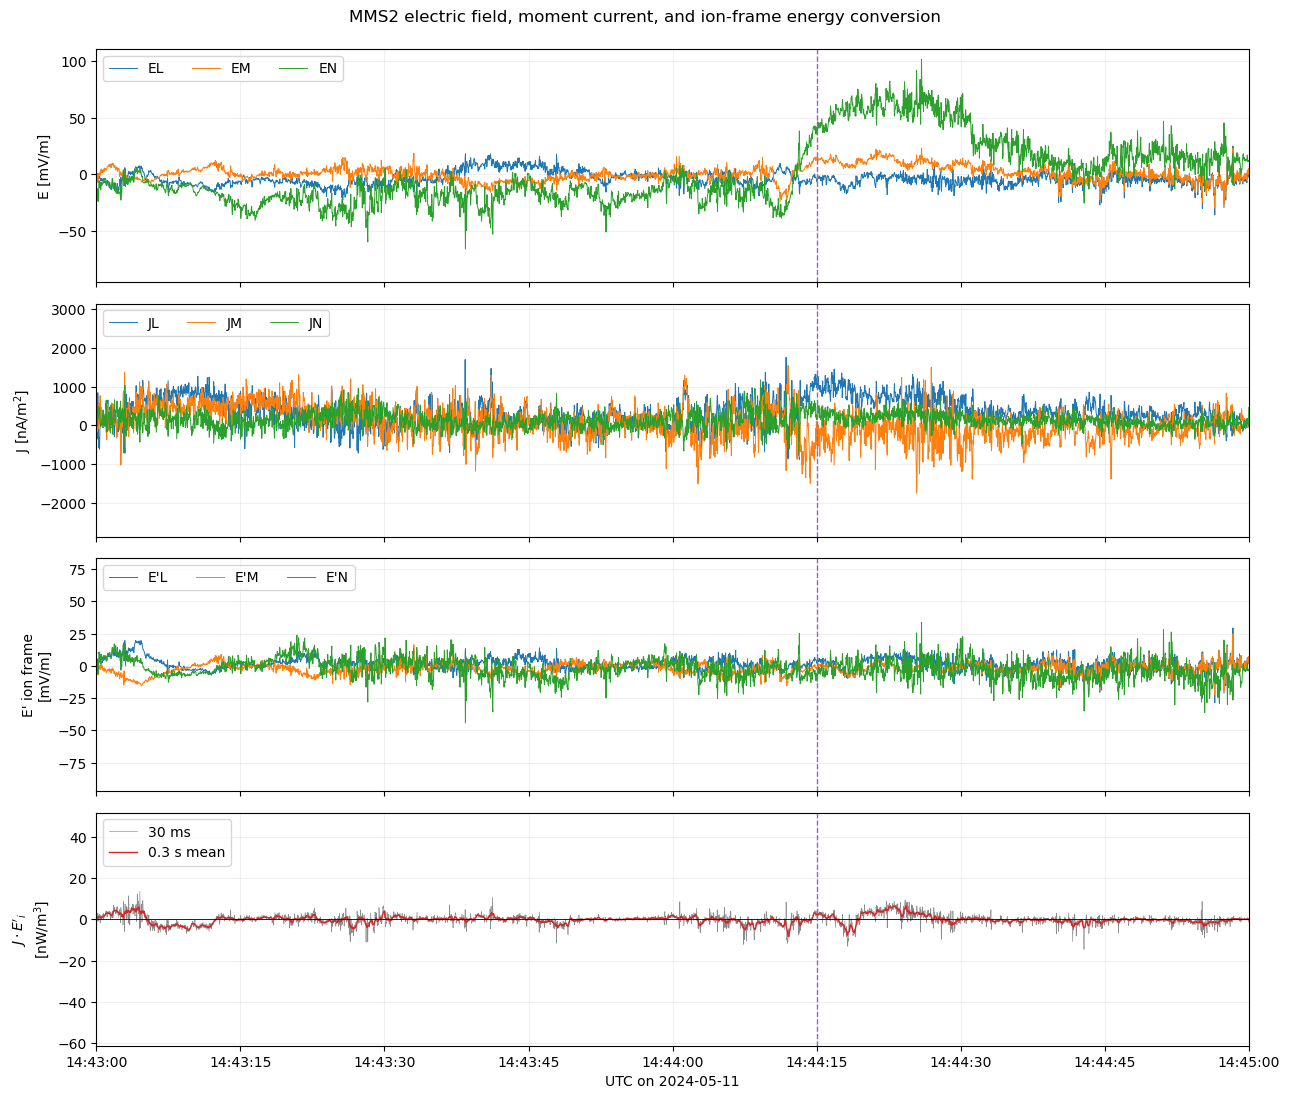

In [16]:
jdot_eprime_nW_m3 = np.einsum(
    "ij,ij->i", j_nA_m2_gse, eprime_mV_m_gse
) * 1e-3

def moving_nanmean(values, samples):
    kernel = np.ones(samples)
    finite = np.isfinite(values)
    numerator = np.convolve(np.where(finite, values, 0.0), kernel, mode="same")
    denominator = np.convolve(finite.astype(float), kernel, mode="same")
    return np.divide(numerator, denominator, out=np.full_like(values, np.nan),
                     where=denominator > 0)

jdot_smoothed = moving_nanmean(jdot_eprime_nW_m3, samples=10)  # about 0.3 s
store_data("mms2_jdot_eprime_i_standard", data={"x": electron_times, "y": jdot_eprime_nW_m3})
options("mms2_jdot_eprime_i_standard", "ysubtitle", "standard moments [nW/m^3]")

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for component, (label, color) in enumerate(zip(["L", "M", "N"], colors)):
    axes[0].plot(utc_datetimes(electron_times), e_lmn_at_e[:, component],
                 color=color, lw=0.7, label=f"E{label}")
    axes[1].plot(utc_datetimes(electron_times), j_nA_m2_lmn[:, component],
                 color=color, lw=0.7, label=f"J{label}")
    axes[2].plot(utc_datetimes(electron_times), eprime_mV_m_lmn[:, component],
                 color=color, lw=0.7, label=f"E'{label}")
axes[0].set_ylabel("E [mV/m]")
axes[1].set_ylabel(r"J [nA/m$^2$]")
axes[2].set_ylabel("E' ion frame\n[mV/m]")
for ax in axes[:3]:
    ax.legend(ncol=3, loc="upper left")

axes[3].plot(utc_datetimes(electron_times), jdot_eprime_nW_m3,
             color="0.55", lw=0.45, label="30 ms")
axes[3].plot(utc_datetimes(electron_times), jdot_smoothed,
             color="red", lw=1.0, label="0.3 s mean")
axes[3].axhline(0, color="black", lw=0.6)
axes[3].set_ylabel(r"$J\cdot E'_i$" + "\n[nW/m$^3$]")
axes[3].legend(loc="upper left")

for ax in axes:
    ax.axvline(crossing_dt, color="purple", ls="--", lw=1)
    ax.grid(alpha=0.18)
    ax.set_xlim(plot_start, plot_stop)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
axes[-1].set_xlabel("UTC on 2024-05-11")
fig.suptitle("MMS2 electric field, moment current, and ion-frame energy conversion", y=0.995)
fig.tight_layout()

focus_mask = (
    (electron_times >= time_double(focused_trange[0]))
    & (electron_times <= time_double(focused_trange[1]))
)
for label, values in [
    ("|J| [nA/m^2]", np.linalg.norm(j_nA_m2_gse, axis=1)),
    ("|E'| [mV/m]", np.linalg.norm(eprime_mV_m_gse, axis=1)),
    ("J.E' [nW/m^3]", jdot_eprime_nW_m3),
]:
    selected = values[focus_mask & np.isfinite(values)]
    print(label, "1st/50th/99th percentiles:", np.percentile(selected, [1, 50, 99]).round(3))

Positive $\mathbf J\cdot\mathbf E'_i$ means local transfer from electromagnetic fields to particles in the ion bulk-flow frame; negative values mean the reverse. The alternating signs show why this is a local diagnostic, not a global energy budget. Here the current and therefore the dot product inherit the limitations of the standard DES moments.

## 12. Recompute DES moments above 32.8 eV

In the high-density magnetosheath and boundary layer, FPI/DES observed a large population of low-energy secondary electrons produced by the spacecraft environment. Beedle et al. therefore excluded DES energies below **32.8 eV** and applied the velocity spin-tone correction.

PySPEDAS can apply the same energy restriction directly to the 3-D burst distributions with `mms_part_products`. We limit this computationally intensive step to 14:44:00–14:44:30 UT around the complete crossing. The two required distribution CDFs total roughly 730 MB; after they are cached, integrating 1,000 distributions takes about 6–7 minutes in the development environment.

We supply spacecraft potential to the integration. We leave the routine's optional generic photoelectron-model subtraction off: the explicit 32.8 eV cut is the correction under study, and it should not be conflated with the paper's complete FPI-team processing chain. The generated moments remain a transparent teaching reconstruction rather than an official instrument-team product.

In [17]:
partial_trange = ["2024-05-11/14:44:00", "2024-05-11/14:44:30"]

des_dist_vars = mms.fpi(
    probe="2", trange=partial_trange, data_rate="brst",
    datatype="des-dist", time_clip=True,
)
scpot_vars = mms.edp(
    probe="2", trange=partial_trange, data_rate="brst", level="l2",
    datatype="scpot", varformat="*_edp_scpot_*", time_clip=True,
)
mec_vars = mms.mec(
    probe="2", trange=partial_trange, data_rate="srvy", level="l2",
    datatype="epht89q",
    varformat="*_mec_quat_eci_to_dbcs*|*_mec_quat_eci_to_gse*",
    time_clip=True,
)

for name in [
    "mms2_des_dist_brst", "mms2_edp_scpot_brst_l2",
    "mms2_mec_quat_eci_to_dbcs", "mms2_mec_quat_eci_to_gse",
]:
    if get_data(name) is None:
        raise RuntimeError(f"Required partial-moment input {name!r} was not loaded")

print(f"DES distribution loader returned {len(des_dist_vars)} variables")
print(f"Spacecraft-potential loader returned {len(scpot_vars)} variables")
print(f"MEC loader returned {len(mec_vars)} variables")

24-Sep-26 10:41:52: Loading files for group: probe: 2, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:


24-Sep-26 10:41:52: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fpi/brst/l2/des-dist/2024/05/11/mms2_fpi_brst_l2_des-dist_20240511144203_v3.4.0.cdf


24-Sep-26 10:41:52: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/fpi/brst/l2/des-dist/2024/05/11/mms2_fpi_brst_l2_des-dist_20240511144413_v3.4.0.cdf


24-Sep-26 10:42:02: The name mms2_dis_compressionloss_brst_dist is currently not in pyspedas


24-Sep-26 10:42:02: The name mms2_dis_compressionloss_brst_dist is currently not in pyspedas


...

24-Sep-26 10:42:02: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/scpot/2024/05/11/mms2_edp_brst_l2_scpot_20240511144203_v2.9.1.cdf


24-Sep-26 10:42:02: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/edp/brst/l2/scpot/2024/05/11/mms2_edp_brst_l2_scpot_20240511144413_v2.9.1.cdf


24-Sep-26 10:42:04: Loading files for group: probe: 2, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:


24-Sep-26 10:42:04: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/mec/srvy/l2/epht89q/2024/05/mms2_mec_srvy_l2_epht89q_20240511_v2.2.2.cdf


DES distribution loader returned 26 variables
Spacecraft-potential loader returned 1 variables
MEC loader returned 3 variables


In [18]:
partial_vars = mms_part_products(
    "mms2_des_dist_brst",
    instrument="fpi", species="e", probe="2", data_rate="brst",
    output=["energy", "moments"], units="eflux",
    energy=[32.8, 30000.0],
    mag_name="mms2_fgm_b_gse_brst_l2_bvec",
    sc_pot_name="mms2_edp_scpot_brst_l2",
    correct_photoelectrons=False,
    prefix="partial_", suffix="_e32p8",
)

partial_spectrum_var = "partial_mms2_des_dist_brst_energy_e32p8"
partial_density_var = "partial_mms2_des_dist_brst_density_e32p8"
partial_velocity_dbcs_var = "partial_mms2_des_dist_brst_velocity_e32p8"
partial_velocity_gse_var = "partial_mms2_des_dist_brst_velocity_gse_e32p8"

for name in [partial_spectrum_var, partial_density_var, partial_velocity_dbcs_var]:
    if name not in partial_vars or get_data(name) is None:
        raise RuntimeError(f"mms_part_products did not create {name!r}")

# mms_part_products returns non-FAC FPI vector moments in DBCS.
mms.mms_qcotrans(
    partial_velocity_dbcs_var, partial_velocity_gse_var,
    in_coord="dbcs", out_coord="gse", probe="2",
)

partial_density_data = get_data(partial_density_var)
partial_velocity_gse_data = get_data(partial_velocity_gse_var)
partial_times = partial_density_data.times
assert np.array_equal(partial_times, partial_velocity_gse_data.times)

# Apply the delivered spin-tone error estimate after rotation to GSE.
spintone_at_partial = interp_columns(
    electron_spintone_data.times, electron_spintone_data.y, partial_times
)
partial_velocity_corrected_gse = partial_velocity_gse_data.y - spintone_at_partial

print("Partial-moment samples:", len(partial_times))
print("Partial density range [cm^-3]:",
      np.nanmin(partial_density_data.y).round(2), "to",
      np.nanmax(partial_density_data.y).round(2))

24-Sep-26 10:42:04: tinterpol (linear) was applied to: mms2_fgm_b_gse_brst_l2_bvec_pgs_temp


24-Sep-26 10:42:04: tinterpol (linear) was applied to: mms2_edp_scpot_brst_l2_pgs_temp


24-Sep-26 10:42:04: ==================================================================================


24-Sep-26 10:42:04: WARNING:


24-Sep-26 10:42:04: Moments generated with mms_part_products may be missing several important
corrections, including photoelectron removal and spacecraft potential.
The official moments released by the instrument teams include these and
are the scientific products that should be used for analysis.


...

24-Sep-26 10:48:47: Interpolating the MEC quaternions to the data time stamps.


24-Sep-26 10:48:47: Setting coordinate system for partial_mms2_des_dist_brst_velocity_gse_e32p8


24-Sep-26 10:48:47: Interpolating the MEC quaternions to the data time stamps.


24-Sep-26 10:48:47: Setting coordinate system for partial_mms2_des_dist_brst_velocity_gse_e32p8


Partial-moment samples: 1000
Partial density range [cm^-3]: 17.03 to 74.47


### Compare standard and energy-limited electron products

Removing the low-energy bins changes both density and bulk velocity. It does not force $n_e=n_i$, nor should it: interpolation, calibration, remaining backgrounds, and the distinction between this reconstruction and the FPI team's processing still matter.

n_e(partial) / n_e(standard), 1st/50th/99th percentiles: [0.829 0.879 0.89 ]
RMS partial-minus-standard V_e in GSE [km/s]: [10.44 21.42 32.57]


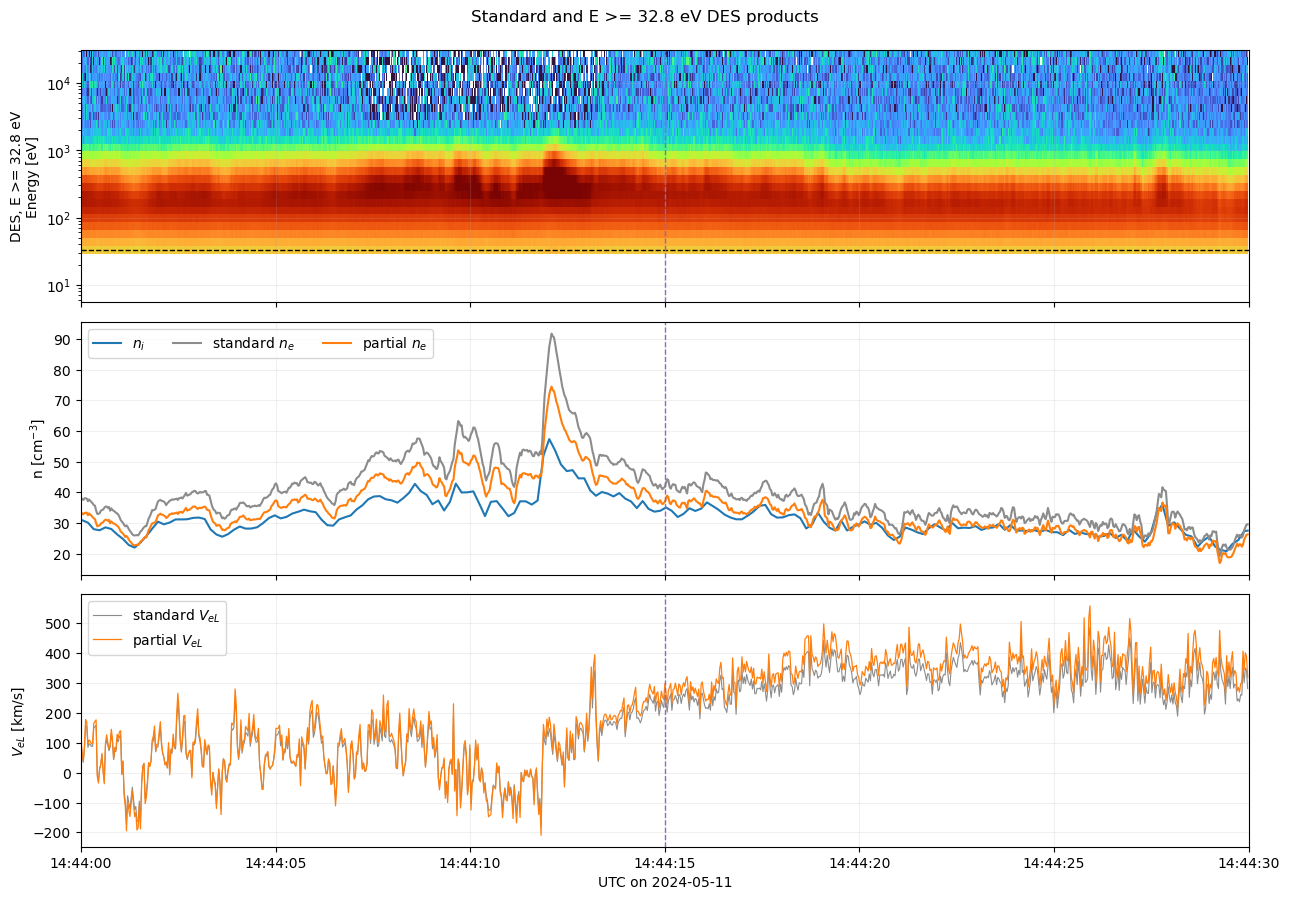

In [19]:
standard_ne_at_partial = interp_columns(
    electron_density_data.times, electron_density_data.y, partial_times
)
ion_n_at_partial = interp_columns(
    ion_density_data.times, ion_density_data.y, partial_times
)
standard_ve_at_partial = interp_columns(
    electron_velocity_data.times,
    electron_velocity_corrected_gse,
    partial_times,
)

partial_ve_lmn = partial_velocity_corrected_gse @ R_gse_to_lmn.T
standard_ve_lmn_at_partial = standard_ve_at_partial @ R_gse_to_lmn.T
density_ratio = partial_density_data.y / standard_ne_at_partial
print("n_e(partial) / n_e(standard), 1st/50th/99th percentiles:",
      np.nanpercentile(density_ratio, [1, 50, 99]).round(3))
print("RMS partial-minus-standard V_e in GSE [km/s]:",
      np.sqrt(np.nanmean(
          (partial_velocity_corrected_gse - standard_ve_at_partial) ** 2,
          axis=0,
      )).round(2))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
add_spectrogram(axes[0], partial_spectrum_var, "DES, E >= 32.8 eV", cutoff=32.8)
axes[1].plot(utc_datetimes(partial_times), ion_n_at_partial,
             color="blue", label=r"$n_i$")
axes[1].plot(utc_datetimes(partial_times), standard_ne_at_partial,
             color="0.55", label=r"standard $n_e$")
axes[1].plot(utc_datetimes(partial_times), partial_density_data.y,
             color="orange", label=r"partial $n_e$")
axes[1].set_ylabel(r"n [cm$^{-3}$]")
axes[1].legend(loc="upper left", ncol=3)

axes[2].plot(utc_datetimes(partial_times), standard_ve_lmn_at_partial[:, 0],
             color="0.55", lw=0.8, label=r"standard $V_{eL}$")
axes[2].plot(utc_datetimes(partial_times), partial_ve_lmn[:, 0],
             color="orange", lw=0.9, label=r"partial $V_{eL}$")
axes[2].set_ylabel(r"$V_{eL}$ [km/s]")
axes[2].legend(loc="upper left")

partial_start, partial_stop = [
    datetime.fromtimestamp(t, tz=timezone.utc) for t in time_double(partial_trange)
]
for ax in axes:
    ax.axvline(crossing_dt, color="purple", ls="--", lw=1)
    ax.grid(alpha=0.18)
    ax.set_xlim(partial_start, partial_stop)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
axes[-1].set_xlabel("UTC on 2024-05-11")
fig.suptitle("Standard and E >= 32.8 eV DES products", y=0.995)
fig.tight_layout()

### Recalculate current and energy conversion with partial moments

We retain ion density in $\mathbf J=e n_i(\mathbf V_i-\mathbf V_e)$, as in the paper, but now use the energy-limited, spin-tone-corrected electron velocity. $\mathbf E'_i$ is unchanged by the electron correction; only $\mathbf J$ and therefore $\mathbf J\cdot\mathbf E'_i$ change.

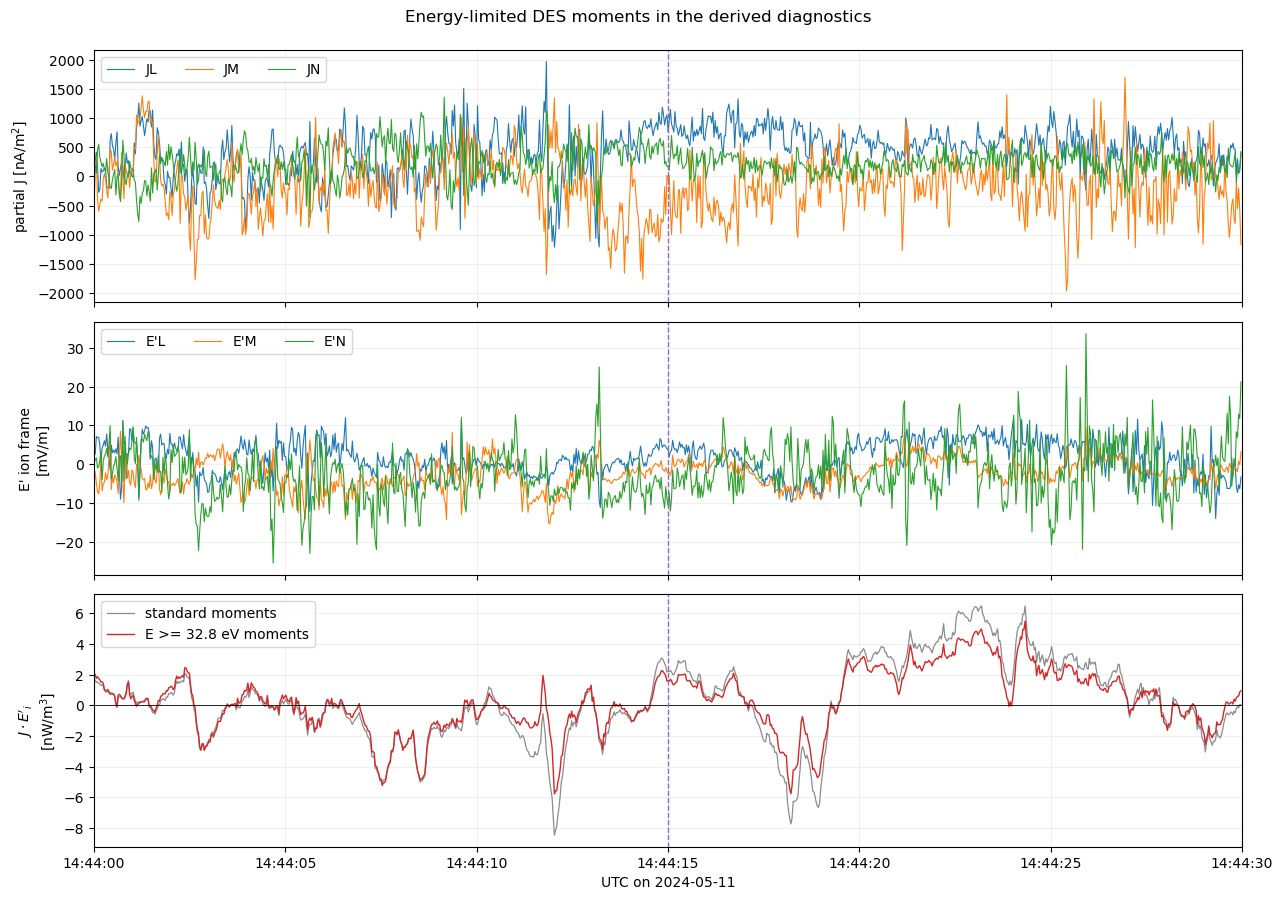

In [20]:
vi_at_partial = interp_columns(
    ion_velocity_data.times, ion_velocity_data.y, partial_times
)
b_at_partial = interp_columns(b_data.times, b_gse, partial_times)
e_at_partial = bin_average(e_data.times, e_data.y, partial_times)

j_partial_nA_m2_gse = (
    elementary_charge
    * (ion_n_at_partial * 1e6)[:, None]
    * ((vi_at_partial - partial_velocity_corrected_gse) * 1e3)
    * 1e9
)
j_standard_nA_m2_gse = (
    elementary_charge
    * (ion_n_at_partial * 1e6)[:, None]
    * ((vi_at_partial - standard_ve_at_partial) * 1e3)
    * 1e9
)
eprime_at_partial = e_at_partial + np.cross(vi_at_partial, b_at_partial) * 1e-3
jdot_partial = np.einsum("ij,ij->i", j_partial_nA_m2_gse, eprime_at_partial) * 1e-3
jdot_standard = np.einsum("ij,ij->i", j_standard_nA_m2_gse, eprime_at_partial) * 1e-3

j_partial_lmn = j_partial_nA_m2_gse @ R_gse_to_lmn.T
eprime_partial_lmn = eprime_at_partial @ R_gse_to_lmn.T

store_data(
    "mms2_fpi_j_lmn_partial_e32p8",
    data={"x": partial_times, "y": j_partial_lmn},
)
store_data(
    "mms2_jdot_eprime_i_partial_e32p8",
    data={"x": partial_times, "y": jdot_partial},
)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for component, (label, color) in enumerate(zip(["L", "M", "N"], colors)):
    axes[0].plot(utc_datetimes(partial_times), j_partial_lmn[:, component],
                 color=color, lw=0.8, label=f"J{label}")
    axes[1].plot(utc_datetimes(partial_times), eprime_partial_lmn[:, component],
                 color=color, lw=0.8, label=f"E'{label}")
axes[0].set_ylabel(r"partial J [nA/m$^2$]")
axes[1].set_ylabel("E' ion frame\n[mV/m]")
axes[0].legend(loc="upper left", ncol=3)
axes[1].legend(loc="upper left", ncol=3)

axes[2].plot(utc_datetimes(partial_times), moving_nanmean(jdot_standard, 10),
             color="0.55", lw=0.9, label="standard moments")
axes[2].plot(utc_datetimes(partial_times), moving_nanmean(jdot_partial, 10),
             color="red", lw=1.0, label="E >= 32.8 eV moments")
axes[2].axhline(0, color="black", lw=0.6)
axes[2].set_ylabel(r"$J\cdot E'_i$" + "\n[nW/m$^3$]")
axes[2].legend(loc="upper left")

for ax in axes:
    ax.axvline(crossing_dt, color="purple", ls="--", lw=1)
    ax.grid(alpha=0.18)
    ax.set_xlim(partial_start, partial_stop)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
axes[-1].set_xlabel("UTC on 2024-05-11")
fig.suptitle("Energy-limited DES moments in the derived diagnostics", y=0.995)
fig.tight_layout()

The energy cutoff generally lowers the reconstructed electron density and changes the velocity enough to alter the moment current and local energy-conversion trace. This is exactly why the caveat cannot be handled by changing only a plot label. Differences from Beedle et al. can remain because the paper used the FPI team's partial-moment processing, whereas this section transparently uses the public distribution and PySPEDAS integration path.

## 13. Ion velocity-space slices across the flow reversal

The ion moments contain two sustained, opposite-sign $V_{iL}$ intervals after the main boundary crossing. A distribution slice tests whether those moment reversals correspond to visibly displaced ion phase-space density rather than a single noisy sample. We select the extrema of a seven-sample (about 1.05 s) running mean, then average the same number of DIS distributions at each time.

FPI distributions are organized in DBCS. To make the comparison physically readable, we use MEC attitude quaternions to map the derived GSE LMN frame into DBCS and pass that matrix to `mms_part_slice2d`. Both panels therefore use the same fixed $V_L$-$V_M$ plane and color scale. The wrapper loads a $\pm60$ s support interval around each requested time, even though only seven samples are averaged.

In [21]:
slice_search = (
    (ion_velocity_data.times >= time_double("2024-05-11/14:44:15"))
    & (ion_velocity_data.times <= time_double("2024-05-11/14:45:40"))
)
vi_l_smooth = np.convolve(
    ion_velocity_lmn[:, 0], np.ones(7) / 7, mode="same"
)
slice_candidates = np.flatnonzero(slice_search & np.isfinite(vi_l_smooth))
positive_jet_index = slice_candidates[np.argmax(vi_l_smooth[slice_candidates])]
negative_jet_index = slice_candidates[np.argmin(vi_l_smooth[slice_candidates])]
slice_centers = ion_velocity_data.times[
    [positive_jet_index, negative_jet_index]
]

for label, index in zip(["positive-L", "negative-L"],
                        [positive_jet_index, negative_jet_index]):
    stamp = datetime.fromtimestamp(
        ion_velocity_data.times[index], tz=timezone.utc
    ).strftime("%H:%M:%S.%f")[:-3]
    print(f"{label:10s} slice center: {stamp} UT, "
          f"<ViL>_7 = {vi_l_smooth[index]:.1f} km/s")

positive-L slice center: 14:44:19.082 UT, <ViL>_7 = 516.7 km/s
negative-L slice center: 14:45:24.633 UT, <ViL>_7 = -145.1 km/s


In [22]:
# Load attitude quaternions across both slice times. The CDF is small and is
# already needed above for the energy-limited electron-velocity rotation.
mms.mec(
    probe="2", trange=["2024-05-11/14:44:00", "2024-05-11/14:45:40"],
    data_rate="srvy", level="l2", datatype="epht89q",
    varformat="*_mec_quat_eci_to_dbcs*|*_mec_quat_eci_to_gse*",
    time_clip=True,
)

def slice_rotation_dbcs_to_lmn(center, label):
    """Return the matrix convention expected by mms_part_slice2d."""
    basis_times = center + np.arange(3) * 1e-4
    input_name = f"slice_basis_dbcs_{label}"
    output_name = f"slice_basis_gse_{label}"
    store_data(input_name, data={"x": basis_times, "y": np.eye(3)})
    mms.mms_qcotrans(
        input_name, output_name,
        in_coord="dbcs", out_coord="gse", probe="2",
    )
    # Each output row is the GSE image of one DBCS basis vector.
    dbcs_to_gse = get_data(output_name).y.T
    dbcs_to_lmn = R_gse_to_lmn @ dbcs_to_gse
    # slice2d maps target-plane grid vectors back into source coordinates.
    return dbcs_to_lmn.T

slice_results = []
for label, center in zip(["plus", "minus"], slice_centers):
    slice_results.append(mms_part_slice2d(
        time=float(center), samples=7,
        probe="2", instrument="fpi", species="i", data_rate="brst",
        rotation="xy",
        custom_rotation=slice_rotation_dbcs_to_lmn(center, label),
        erange=[10.0, 30000.0],
        interpolation="geometric", resolution=180,
        return_slice=True,
    ))

24-Sep-26 10:48:48: Loading files for group: probe: 2, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:


24-Sep-26 10:48:48: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/mec/srvy/l2/epht89q/2024/05/mms2_mec_srvy_l2_epht89q_20240511_v2.2.2.cdf


24-Sep-26 10:48:48: Interpolating the MEC quaternions to the data time stamps.


24-Sep-26 10:48:48: Setting coordinate system for slice_basis_gse_plus


24-Sep-26 10:48:48: Interpolating the MEC quaternions to the data time stamps.


...

24-Sep-26 10:48:57: The name mms2_dis_pitchangdist_lowen_brst is currently not in pyspedas


24-Sep-26 10:48:57: The name mms2_dis_pitchangdist_miden_brst is currently not in pyspedas


24-Sep-26 10:48:57: The name mms2_dis_pitchangdist_highen_brst is currently not in pyspedas


24-Sep-26 10:48:57: Applying custom rotation


24-Sep-26 10:49:03: Finished slice at 2024-05-11 14:45:24.033037


Text(0.5, 0.98, 'MMS2 FPI/DIS distributions across the ion-flow reversal')

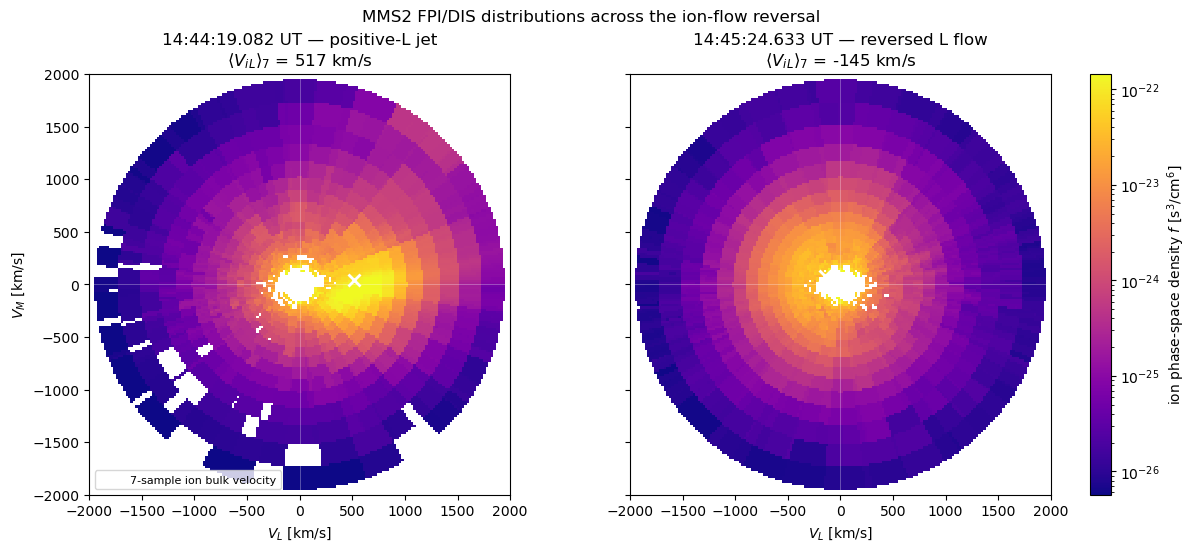

In [23]:
positive_values = np.concatenate([
    result["data"][np.isfinite(result["data"]) & (result["data"] > 0)]
    for result in slice_results
])
color_max = np.nanpercentile(positive_values, 99.8)
color_min = max(np.nanpercentile(positive_values, 2), color_max * 1e-5)
slice_norm = LogNorm(vmin=color_min, vmax=color_max)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5.4), sharex=True, sharey=True,
    constrained_layout=True,
)
meshes = []
for ax, result, center, descriptor in zip(
    axes, slice_results, slice_centers,
    ["positive-L jet", "reversed L flow"],
):
    mesh = ax.pcolormesh(
        result["xgrid"], result["ygrid"], result["data"].T,
        shading="auto", cmap="plasma", norm=slice_norm,
    )
    meshes.append(mesh)
    nearest = np.argsort(np.abs(ion_velocity_data.times - center))[:7]
    bulk_lmn = np.nanmean(ion_velocity_lmn[nearest], axis=0)
    ax.plot(bulk_lmn[0], bulk_lmn[1], marker="x", ms=9, mew=2,
            color="white", label="7-sample ion bulk velocity")
    ax.axhline(0, color="white", alpha=0.35, lw=0.6)
    ax.axvline(0, color="white", alpha=0.35, lw=0.6)
    ax.set_xlim(-2000, 2000)
    ax.set_ylim(-2000, 2000)
    ax.set_aspect("equal")
    stamp = datetime.fromtimestamp(center, tz=timezone.utc).strftime("%H:%M:%S.%f")[:-3]
    ax.set_title(f"{stamp} UT — {descriptor}\n"
                 rf"$\langle V_{{iL}}\rangle_7$ = {bulk_lmn[0]:.0f} km/s")
    ax.set_xlabel(r"$V_L$ [km/s]")
axes[0].set_ylabel(r"$V_M$ [km/s]")
axes[0].legend(loc="lower left", fontsize=8)
fig.colorbar(
    meshes[-1], ax=axes, pad=0.02,
    label=r"ion phase-space density $f$ [s$^3$/cm$^6$]",
)
fig.suptitle("MMS2 FPI/DIS distributions across the ion-flow reversal")

The white crosses show the independently delivered DIS bulk moments and provide a useful coordinate check: the distribution displacement reverses in $V_L$ with the moment. This is evidence for a genuine ion-flow reversal embedded in the exhaust. It is **not**, by itself, proof that MMS crossed the primary X line, and it does not identify the ion composition. DIS measures total positive-ion counts under a proton mass assumption; during this storm, enhanced O$^+$ can contaminate higher-order DIS moments. Species-resolved H$^+$/O$^+$ claims would require HPCA analysis.

## 14. HPCA composition: number density is not mass density

FPI/DIS provides the high-cadence total positive-ion distribution under a proton-mass assumption, but it cannot separate ion species. HPCA adds the missing composition measurement. This distinction is central during the Gannon storm: a few cm$^{-3}$ of heavy ions can rival or exceed the proton **mass** contribution even when protons dominate **number** density.

We load the delivered HPCA burst moments for H$^+$, the standard O$^+$ channel, and He$^{++}$. These moments are spin averaged at about 10 s cadence; the underlying burst ion product is sampled more rapidly, but the moment cadence cannot reproduce every 150 ms DIS extremum. HPCA velocities are delivered in DBCS, so we rotate them to GSE with MEC quaternions before applying the same LMN matrix used throughout the notebook.

In [24]:
hpca_species = ["hplus", "oplus", "heplusplus"]
hpca_labels = [r"H$^+$", r"O$^+$-group", r"He$^{++}$"]
hpca_colors = ["red", "blue", "orange"]
mass_numbers = np.array([1.0, 16.0, 4.0])

hpca_vars = mms.hpca(
    probe="2", trange=trange, data_rate="brst", level="l2",
    datatype="moments", time_clip=True,
)

# Ensure the attitude coverage spans the entire HPCA interval.
mms.mec(
    probe="2", trange=trange, data_rate="srvy", level="l2",
    datatype="epht89q",
    varformat="*_mec_quat_eci_to_dbcs*|*_mec_quat_eci_to_gse*",
    time_clip=True,
)

hpca_density = []
hpca_velocity_lmn = []
hpca_times = None
for species in hpca_species:
    density_name = f"mms2_hpca_{species}_number_density"
    velocity_dbcs_name = f"mms2_hpca_{species}_ion_bulk_velocity"
    velocity_gse_name = f"{velocity_dbcs_name}_gse"

    density_data = get_data(density_name)
    velocity_metadata = get_data(velocity_dbcs_name, metadata=True)
    if density_data is None or get_data(velocity_dbcs_name) is None:
        raise RuntimeError(f"Missing HPCA products for {species}")
    if velocity_metadata["data_att"].get("coord_sys", "").upper() != "DBCS":
        raise RuntimeError(f"Unexpected HPCA velocity coordinates for {species}")

    mms.mms_qcotrans(
        velocity_dbcs_name, velocity_gse_name,
        in_coord="dbcs", out_coord="gse", probe="2",
    )
    velocity_gse_data = get_data(velocity_gse_name)
    if hpca_times is None:
        hpca_times = density_data.times
    if not (np.array_equal(hpca_times, density_data.times)
            and np.array_equal(hpca_times, velocity_gse_data.times)):
        raise RuntimeError("HPCA species moments do not share timestamps")

    hpca_density.append(np.asarray(density_data.y))
    hpca_velocity_lmn.append(
        np.asarray(velocity_gse_data.y) @ R_gse_to_lmn.T
    )

hpca_density = np.column_stack(hpca_density)
hpca_velocity_lmn = np.stack(hpca_velocity_lmn, axis=1)
hpca_mass_density = hpca_density * mass_numbers[None, :]
hpca_mass_fraction = hpca_mass_density / np.nansum(
    hpca_mass_density, axis=1, keepdims=True
)
hpca_cadence = np.nanmedian(np.diff(hpca_times))

print(f"HPCA moments returned {len(hpca_times)} samples; "
      f"median cadence = {hpca_cadence:.2f} s")
print("Median mass contributions [amu cm^-3] (H+, O+-group, He++):",
      np.nanmedian(hpca_mass_density, axis=0).round(2))
print("O+-group mass-fraction percentiles (10/50/90):",
      np.nanpercentile(hpca_mass_fraction[:, 1], [10, 50, 90]).round(3))
print("Samples where O+-group is the largest plotted mass contribution:",
      np.sum(np.argmax(hpca_mass_density, axis=1) == 1),
      "of", len(hpca_times))

24-Sep-26 10:49:04: Loading files for group: probe: 2, drate: brst, level: l2, datatype: moments, after sorting and filtering:


24-Sep-26 10:49:04: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/hpca/brst/l2/moments/2024/05/11/mms2_hpca_brst_l2_moments_20240511143943_v4.3.0.cdf


24-Sep-26 10:49:04: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/hpca/brst/l2/moments/2024/05/11/mms2_hpca_brst_l2_moments_20240511144203_v4.3.0.cdf


24-Sep-26 10:49:04: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/hpca/brst/l2/moments/2024/05/11/mms2_hpca_brst_l2_moments_20240511144413_v4.3.0.cdf


24-Sep-26 10:49:04: /Users/jwl/Documents/Codex/2026-09-23/hre/work/data/mms/mms2/hpca/brst/l2/moments/2024/05/11/mms2_hpca_brst_l2_moments_20240511144633_v4.3.2.cdf


...

24-Sep-26 10:49:05: Interpolating the MEC quaternions to the data time stamps.


24-Sep-26 10:49:05: Setting coordinate system for mms2_hpca_heplusplus_ion_bulk_velocity_gse


24-Sep-26 10:49:05: Interpolating the MEC quaternions to the data time stamps.


24-Sep-26 10:49:05: Setting coordinate system for mms2_hpca_heplusplus_ion_bulk_velocity_gse


HPCA moments returned 33 samples; median cadence = 10.00 s
Median mass contributions [amu cm^-3] (H+, O+-group, He++): [30.87 30.42  9.01]
O+-group mass-fraction percentiles (10/50/90): [0.341 0.451 0.736]
Samples where O+-group is the largest plotted mass contribution: 19 of 33


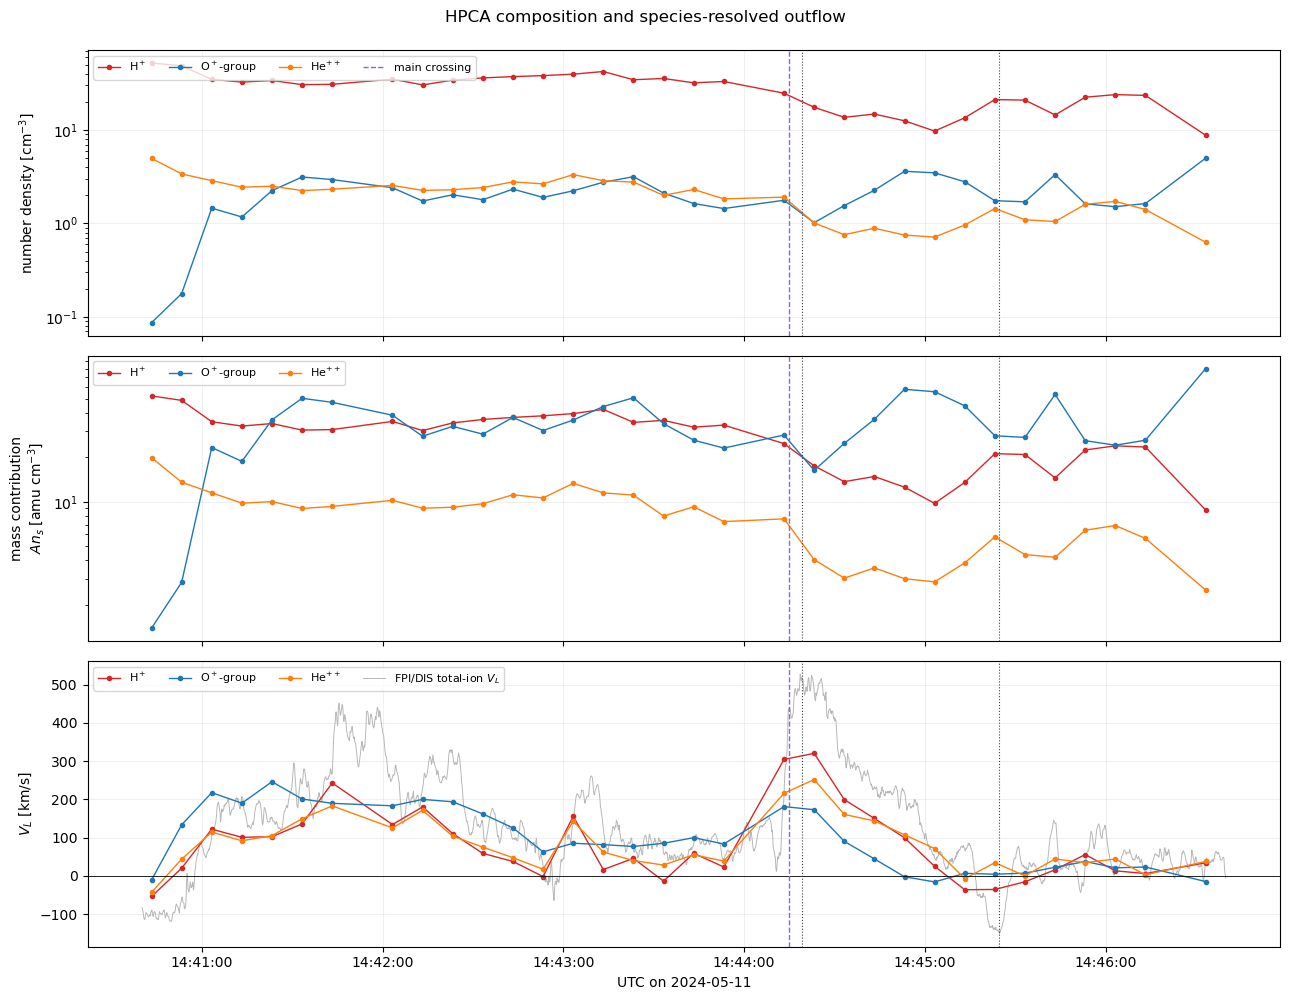

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
hpca_datetimes = utc_datetimes(hpca_times)

for index, (label, color) in enumerate(zip(hpca_labels, hpca_colors)):
    axes[0].semilogy(
        hpca_datetimes, hpca_density[:, index],
        marker="o", ms=3, lw=1.0, color=color, label=label,
    )
    axes[1].semilogy(
        hpca_datetimes, hpca_mass_density[:, index],
        marker="o", ms=3, lw=1.0, color=color, label=label,
    )
    axes[2].plot(
        hpca_datetimes, hpca_velocity_lmn[:, index, 0],
        marker="o", ms=3, lw=1.0, color=color, label=label,
    )

# DIS supplies the high-cadence context; HPCA supplies species identity.
axes[2].plot(
    utc_datetimes(ion_velocity_data.times), ion_velocity_lmn[:, 0],
    color="0.65", lw=0.7, alpha=0.8, label="FPI/DIS total-ion $V_L$",
    zorder=0,
)
axes[0].set_ylabel(r"number density [cm$^{-3}$]")
axes[1].set_ylabel(r"mass contribution" + "\n" + r"$A n_s$ [amu cm$^{-3}$]")
axes[2].set_ylabel(r"$V_L$ [km/s]")
axes[2].axhline(0, color="black", lw=0.6)

for ax in axes:
    ax.axvline(crossing_dt, color="purple", ls="--", lw=1,
               label="main crossing" if ax is axes[0] else None)
    for center in slice_centers:
        ax.axvline(
            datetime.fromtimestamp(center, tz=timezone.utc),
            color="0.25", ls=":", lw=0.8,
        )
    ax.grid(alpha=0.18)
    ax.legend(loc="upper left", ncol=4, fontsize=8)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M:%S", tz=timezone.utc)
)
axes[-1].set_xlabel("UTC on 2024-05-11")
fig.suptitle("HPCA composition and species-resolved outflow", y=0.995)
fig.tight_layout()

The upper two panels make the key composition lesson explicit: number-density dominance and mass-density dominance are different questions. Multiplying by approximate ion mass number ($A=1,16,4$) reveals intervals where the O$^+$-group channel is the largest plotted mass contribution. The bottom panel shows that HPCA H$^+$ and O$^+$-group moments participate differently in the broad outflow evolution, while their 10 s averaging smooths the sharper DIS reversal highlighted by the dotted slice times.

**Composition caveat.** For this storm, the standard HPCA O$^+$ moment channel contains substantial unresolved N$^+$ and N$_2^+$ contributions. We therefore use “O$^+$-group” in interpretation even though the public variable is named `oplus`. The simple $A=16$ conversion is an instructional O$^+$-equivalent mass contribution, not a species-perfect reconstruction. He$^+$ is omitted to keep the comparison focused and because minor-species moments are more vulnerable to contamination in high-proton-flux regions.

## 15. The electron-moment limitation is part of the science

The notebook now shows both levels of analysis:

1. ordinary public moments over the full event, useful for orientation and for exposing the density mismatch;
2. a focused $E\ge32.8$ eV distribution integration with spacecraft potential and spin-tone correction; and
3. standard-versus-partial comparisons of density, velocity, current, and $\mathbf J\cdot\mathbf E'_i$.

The partial products are more appropriate for interpreting the crossing than silently using the standard DES moments, but they remain instructional estimates rather than a bit-for-bit reproduction of the unpublished FPI-team partial-moment pipeline.

## 16. Why we do not use four-spacecraft gradients here

Four MMS spacecraft do not automatically make curlometer, reciprocal-vector, FOTE, or other tetrahedral-gradient calculations valid. Section 3 shows the orbit-scale quality product and the simultaneous four-probe formation directly. Near $7\,R_E$ the constellation was extremely elongated and nearly planar; Beedle et al. also judged tetrahedral techniques nonviable for this event. This notebook therefore remains single-spacecraft for derived current and energy conversion.

## 17. Exercises

**A — Identify the crossing.** Estimate the $B_L=0$ time from the transformed field. How close is it to 14:44:15 UT? Why are there multiple possible zero crossings?

**B — MVA sensitivity.** Repeat MVA after moving either endpoint by 10–30 s. Compare eigenvalue ratios and the angle between trial and original $N$. Is $N$ stable enough for every interpretation?

**C — Ion jet.** Estimate the largest sustained $|V_{iL}|$ in the focused interval and compare its timing with the main magnetic reversal. Avoid reporting a single isolated sample as a jet speed.

**D — One current sample by hand.** At a time you choose, convert $n_i$ to m$^{-3}$ and both velocities to m/s, then evaluate $e n_i(\mathbf V_i-\mathbf V_e)$. Compare with `j_nA_m2_gse`.

**E — One nonideal-field sample by hand.** Calculate $\mathbf V_i\times\mathbf B$ and verify the factor $10^{-3}$ that converts (km/s)(nT) to mV/m. Compare with `eprime_mV_m_gse`.

**F — Interpret energy conversion.** Select one positive and one negative $\mathbf J\cdot\mathbf E'_i$ interval. What does each sign mean locally, and why can neither establish the global energy budget?

**G — Read a velocity-space slice.** Compare the two $V_L$-$V_M$ distributions and their bulk-moment markers. Which features support a bulk reversal, and what additional HPCA result would be needed before assigning those features separately to H$^+$ and O$^+$?

**H — Number versus mass.** Find a time when H$^+$ dominates number density but the O$^+$-group channel dominates the plotted mass contribution. Explain why heavy-ion mass loading can matter for reconnection even when $n_{O^+}<n_{H^+}$, and identify the nitrogen caveat in that inference.

**I — Geometry before gradients.** Use the interpolated four-spacecraft positions to reproduce the six pairwise separations. Why does the normalized principal-extent ratio $1:0.25:0.03$ warn against tetrahedral gradients? Why must the missing quality-factor interval not be filled by linear interpolation?

In [26]:
# Starter for Exercise B: adjust the endpoints, rerun, and compare.
# trial_trange = ["2024-05-11/14:40:55", "2024-05-11/14:46:25"]
# trial_start, trial_stop = time_double(trial_trange)
# trial_mask = (
#     (b_data.times >= trial_start) & (b_data.times <= trial_stop)
#     & np.all(np.isfinite(b_gse), axis=1) & (b_flag_data.y == 0)
# )
# _, trial_vectors, trial_values = minvar(b_gse[trial_mask])
# trial_R = trial_vectors.T
# print(trial_values)
# print(trial_R)

## 18. Scientific takeaway

MMS2 encountered an exceptionally compressed dayside magnetopause during the Gannon storm. Burst magnetic field, spectra, density, and flows show a structured boundary with a complete reversal near 14:44:15 UT and reconnection-related jet signatures. HPCA establishes that the boundary was compositionally unusual: the O$^+$-group channel frequently rivaled or exceeded H$^+$ in mass contribution even while H$^+$ dominated number density. The formation snapshot demonstrates why having four spacecraft does not guarantee trustworthy spatial gradients. MVA supplies a useful single-spacecraft LMN frame, although its weaker intermediate/minimum separation makes sensitivity testing important. Combining carefully aligned moments and fields yields an estimated current, ion-frame nonideal field, and local energy-conversion diagnostic.

The most important lesson is methodological: high-resolution loaders are only the beginning. Coordinate metadata, sign conventions, cadence matching, unit conversions, constellation geometry, energy-bin selection, and instrument-specific contamination determine whether a sophisticated-looking result is scientifically meaningful.

## References and data notes

- Beedle, J. M. H., et al. (2025), *MMS Observations of a Compressed, Strongly Driven Magnetopause During the 2024 Mother's Day Storm*, **Geophysical Research Letters**, 52, e2025GL118368, [doi:10.1029/2025GL118368](https://doi.org/10.1029/2025GL118368).
- Burch, J. L., et al. (2016), *Magnetospheric Multiscale overview and science objectives*, **Space Science Reviews**, 199, 5–21.
- Pollock, C., et al. (2016), *Fast Plasma Investigation for Magnetospheric Multiscale*, **Space Science Reviews**, 199, 331–406.
- Young, D. T., et al. (2016), *Hot Plasma Composition Analyzer for the Magnetospheric Multiscale Mission*, **Space Science Reviews**, 199, 407–470.
- Russell, C. T., et al. (2016), *The Magnetospheric Multiscale Magnetometers*, **Space Science Reviews**, 199, 189–256.
- Lindqvist, P.-A., et al. (2016), *The Spin-Plane Double Probe Electric Field Instrument for MMS*, **Space Science Reviews**, 199, 137–165.
- Sonnerup, B. U. Ö., and M. Scheible (1998), minimum and maximum variance analysis, in *Analysis Methods for Multi-Spacecraft Data*.

Data are public MMS Level-2 burst products from FGM, FPI, EDP, MEC, and HPCA, loaded from the MMS Science Data Center through PySPEDAS 2.2.0.

## Instructor notes and current caveats

- Validated products for MMS2 span the full interval: FGM 128 Hz, DIS moments 150 ms, DES moments 30 ms, and EDP 8192 Hz.
- With current Level-2 files, the MVA eigenvalues are approximately `[8055, 993, 421]` nT$^2$; $L$ is within about $4.5^\circ$ of the published direction, while $M/N$ differ by about $23^\circ$.
- The nearest $B_L=0$ sample in a $\pm10$ s search around the reported crossing is approximately 14:44:13.85 UT.
- The advanced section uses `mms_part_products` with `energy=[32.8, 30000.0]`, spacecraft potential, DBCS-to-GSE quaternion rotation, and the delivered spin-tone error estimate. It produces 1,000 native-cadence samples over 14:44:00–14:44:30 UT and took about 6.6 minutes after data were cached.
- Two DES distribution files (roughly 730 MB total) are required because the focused interval straddles a burst-file boundary. Extending the integration to the entire six-minute overview would require roughly 1.5 GB and substantially longer computation.
- The paired `mms_part_slice2d` figure adds two DIS distribution files (roughly 122 MB total). The selected seven-sample averages have $\langle V_{iL}\rangle$ of about +517 and -145 km/s at 14:44:19.08 and 14:45:24.63 UT, respectively.
- HPCA burst moment files add less than 1 MB. The delivered species moments contain 33 samples across the overview at about 10 s cadence; they complement rather than replace the 150 ms DIS moments.
- The 24-hour tetrahedron-quality load returns 1,499 samples at 30 s cadence, but the target lies within an approximately 11.5-hour ancillary-product gap bracketed by zero values. No event-time quality value is inferred across that gap.
- The 14:44:15 UT MEC snapshot has a barycenter near `[6.038, -2.932, -0.020]` $R_E$, pairwise separations of roughly 15–76 km, and normalized principal formation extents near `[1, 0.255, 0.029]`. This directly supports rejecting tetrahedral-gradient methods.
- `mms_part_products` emits a general warning that generated moments can lack instrument-team corrections. Supplying spacecraft potential and applying the energy cut addresses key issues here, but the result is still not identical to the team's published partial moments.
- The standard HPCA `oplus` moment includes unresolved N$^+$/N$_2^+$ during this storm. The notebook labels it O$^+$-group and treats $16n$ as an O$^+$-equivalent teaching estimate, not an exact heavy-ion mass reconstruction.
- Do not add a curlometer or other tetrahedral derivative: the early geometry section demonstrates that the required three-dimensional formation quality is absent here.